<a href="https://colab.research.google.com/github/swhoyle/electric-load-forecasting/blob/main/Electric_Load_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electric Load Forecasting

**Project Title:** Daily Electric Load Forecasting  
**School:** University of California, San Diego (UCSD)   
**Course:** MAS DSE 260 - Capstone Project   
**Date:** Sprint 2026   
**Team Members:** Sean He, Spencer Hoyle, Frank Chavezsosa   
**Advisor:** Prof. Raymond de Callafon (callafon@ucsd.edu)   


## Project Details

### Objective



Build a model to predict and forecast electric load.

### Dataset

A commercial business (Bakery) in Europe has provided 1-second power load data in Watts (W) recorded by electric meters in the business facilities.

**Structure**:

- Date range:  11/28/2025 → 4/8/2026
- Total days:  132  
- Shape:      (11404800, 3)

| timestamp | day_class | load |
| --- | --- | --- |
| 11-28-2025 00:00:01 | full | 1234 |
| 11-28-2025 00:00:02 | half | 0 |
| ... |... |
| 04-08-2026 12:59:59 | none | -242 |


**Attributes**:
- `timestamp`: The specific date and time of each power reading, recorded at 1-second intervals in local time to the commercial facility.
- `day_class`: The work day classification for the commercial business, provided by the customer.
  - `full`: Full working day (both facility and bakery are open)
  - `half`: Half working day (only facility is open; bakery is closed)
  - `none`: Not a working day (both facility and bakery are closed)
- `load` (predictor): Net power draw from the grid in Watts.
  - Positive (+): either pure load consumption when solar is inactive, or consumption exceeding solar output.
  - Negative (-): Solar output exceeds consumption, sending surplus power back to the grid.
  - Zero (0): No net grid exchange, either because everything is off or solar output exactly matches consumption.

### Steps

1. **Exploratory Data Analysis (EDA)**: Explore the dataset to understand patterns, distributions, and data quality.
2. **Data Cleaning**: Flag missing values, zeros, and outliers.
3. **Downsample**: Downsample from 1-second to target resolutions (1min, 5min, 10min, 15min, 30min, 1hour) by averaging load per interval.
4. **Feature Engineering**: Build time-based, cyclical, solar proxy, lag, rolling, and trend features for each resolution.
5. **Data Preprocessing**: Encode, scale, and split data into train/validation/test sets by time.
6. **Baseline Model**: Predict average load per time-of-day and workday class as a naive benchmark.
7. **Model Training**: Train different models across forecast horizons and hyperparameters.
8. **Model Evaluation**: Compare models against the baseline using MAE, RMSE, and MAPE.
9. **Results & Analysis**: Summarize findings, identify the best model, and discuss limitations.

### Resolutions

Resolution defines how frequently your data is sampled (i.e., the time step between observations).

| Resolution | Intervals/Day | Description |
|------------|--------------|-------------|
| `1sec` | 86,400 | Raw resolution — instantaneous load recorded by the meter |
| `1min` | 1,440 | High granularity, captures minute-level patterns |
| `5min` | 288 | Moderate granularity, reduces noise |
| `10min` | 144 | Balanced granularity |
| `15min` | 96 | Standard energy industry resolution |
| `30min` | 48 | Coarser, captures half-hour load blocks |
| `1hr` | 24 | Low granularity, captures hourly patterns |

Our data has a raw resolution of 1-second, where each value is the instantaneous load recorded by the meter. When we downsample to a lower resolution, we take the average load within that interval:

- `1min`: Average of 60 1-second readings → represents avg load for that minute
- `5min`: Average of 300 1-second readings → represents avg load for that 5-minute block
- `15min`: Average of 900 1-second readings → represents avg load for that 15-minute block

### Our Forecast Approach

This project takes a **horizon-based forecasting** approach first, then **multi-step forecast profiles** after we find the best models for each individual forecast horizon.

#### Phase 1 - Horizion-Based Forecasting

A forecast horizon defines how far into the future the model predicts. For each horizon, the model predicts a single value — the expected average load for that future time interval.

We will focus on the following horizons for our forecasting:

| Horizon | Predicts | Resolution (Downsample) |
|---------|----------|----------|
| `1min` | Expected avg load over the next minute | `1min` |
| `5min` | Expected avg load over the next 5 minutes | `5min` |
| `10min` | Expected avg load over the next 10 minutes | `10min` |
| `15min` | Expected avg load over the next 15 minutes | `15min` |
| `30min` | Expected avg load over the next 30 minutes | `30min` |
| `1hr` | Expected avg load over the next hour | `1hr` |

For each horizon, we will downsample the data to match the horizon resolution.

Our goal is to find the **best model for each horizon**.

#### Phase 2 - Multi-step Forecasting

A forecast profile (multi-step forecast) predicts a sequence of future values, not just one point. The number of predicted steps depends on both the horizon and the resolution.

| Profile | Horizon (Window) | Resolution | Predicted Steps | Example |
|---------|---------|------------|-----------------|---------|
| Short-term | 1 hour | `1min` | 60 steps | Predict every minute for the next hour |
| Short-term | 1 hour | `5min` | 12 steps | Predict every 5 minutes for the next hour |
| Short-term | 1 hour | `10min` | 6 steps | Predict every 10 minutes for the next hour |
| Medium-term | 6 hours | `5min` | 72 steps | Predict every 5 minutes for the next 6 hours |
| Medium-term | 6 hours | `15min` | 24 steps | Predict every 15 minutes for the next 6 hours |
| Medium-term | 6 hours | `30min` | 12 steps | Predict every 30 minutes for the next 6 hours |
| Long-term | 24 hours | `15min` | 96 steps | Predict every 15 minutes for the next 24 hours |
| Long-term | 24 hours | `30min` | 48 steps | Predict every 30 minutes for the next 24 hours |
| Long-term | 24 hours | `1hr` | 24 steps | Predict every hour for the next 24 hours |


**Notes**:

* Each profile outputs **multiple future values** (a time series), not a single prediction
* The number of predicted steps depends on the data resolution
* Profiles are defined by **forecast horizon (time range)** and evaluated across multiple **resolutions**
* Profiles are used to understand both **magnitude and shape** of future load



##### Forecasting Strategies

When predicting a full forecast profile (sequence of future values), there are two fundamental strategies:

###### Strategy 1 — Direct Multi-Step



Train a separate model for each step ahead. Each model is independently optimized to predict exactly N steps into the future using only known past data.

```
Model_1  → predicts load at t+1
Model_2  → predicts load at t+2
...
Model_N  → predicts load at t+N
```

| | |
|--|--|
| ✅ | No error accumulation — each model sees real data |
| ✅ | Each model optimized for its specific horizon |
| ✅ | Most accurate in practice |
| ❌ | More models to train |

###### Strategy 2 — Recursive Multi-Step

Train a single model that predicts one step ahead, then feed that prediction back as a lag feature to predict the next step, and so on.

```
Model → t+1 (predicted) → feed back as lag → t+2 (predicted) → ...
```

| | |
|--|--|
| ✅ | Only one model to train |
| ❌ | Errors compound — small mistakes amplify over each step |
| ❌ | Later predictions are based on predicted values, not real ones |
| ❌ | Accuracy degrades significantly at longer horizons |


##### Forecast Experiment Matrix

This project forecasts electric load across three forecast profiles, each representing a different planning horizon. For each profile, models are trained and evaluated at multiple data resolutions and using two forecasting strategies.


| Profile | Horizon (Window) | Resolutions | Strategies | Experiments |
|---------|---------|-------------|------------|-------------|
| Short-term | 1 hour | `1min`, `5min`, `10min` | Direct, Recursive | 6 |
| Medium-term | 6 hours | `5min`, `15min`, `30min` | Direct, Recursive | 6 |
| Long-term | 24 hours | `15min`, `30min`, `1hr` | Direct, Recursive | 6 |

###### Short-Term Profile (1 hour)


There are 6 short-term profile experiments:

| Key | Profile | Horizon (Window) | Resolution | Strategy | Steps | Total Steps | Total Models |
|-----|---------|---------|------------|----------|-------|-------------|--------------|
| `1h_1min_d` | Short-term | 1 hour | `1min` | Direct | 1, 5, 10, 15, 30, 60 | 6 | 6 |
| `1h_1min_r` | Short-term | 1 hour | `1min` | Recursive | — | 60 | 1 |
| `1h_5min_d` | Short-term | 1 hour | `5min` | Direct | 1, 2, 3, 6, 12 | 5 | 5 |
| `1h_5min_r` | Short-term | 1 hour | `5min` | Recursive | — | 12 | 1 |
| `1h_10min_d` | Short-term | 1 hour | `10min` | Direct | 1, 2, 3, 6 | 4 | 4 |
| `1h_10min_r` | Short-term | 1 hour | `10min` | Recursive | — | 6 | 1 |

###### Medium-Term Profile (6 hour)

There are 6 medium-term profile experiments:


| Key | Profile | Horizon (Window) | Resolution | Strategy | Steps | Total Steps | Total Models |
|-----|---------|---------|------------|----------|-------|-------------|--------------|
| `6h_5min_d` | Medium-term | 6 hours | `5min` | Direct | 1, 3, 6, 12, 36, 72 | 6 | 6 |
| `6h_5min_r` | Medium-term | 6 hours | `5min` | Recursive | — | 72 | 1 |
| `6h_15min_d` | Medium-term | 6 hours | `15min` | Direct | 1, 2, 4, 8, 24 | 5 | 5 |
| `6h_15min_r` | Medium-term | 6 hours | `15min` | Recursive | — | 24 | 1 |
| `6h_30min_d` | Medium-term | 6 hours | `30min` | Direct | 1, 2, 4, 12 | 4 | 4 |
| `6h_30min_r` | Medium-term | 6 hours | `30min` | Recursive | — | 12 | 1 |


###### Long-Term Profile (24 hour)

There are 6 long-term profile experiements:

| Key | Profile | Horizon (Window) | Resolution | Strategy | Steps | Total Steps | Total Models |
|-----|---------|---------|------------|----------|-------|-------------|--------------|
| `24h_15min_d` | Long-term | 24 hours | `15min` | Direct | 1, 2, 4, 12, 24, 48, 96 | 7 | 7 |
| `24h_15min_r` | Long-term | 24 hours | `15min` | Recursive | — | 96 | 1 |
| `24h_30min_d` | Long-term | 24 hours | `30min` | Direct | 1, 2, 6, 12, 24, 48 | 6 | 6 |
| `24h_30min_r` | Long-term | 24 hours | `30min` | Recursive | — | 48 | 1 |
| `24h_1hr_d` | Long-term | 24 hours | `1hr` | Direct | 1, 2, 3, 6, 12, 24 | 6 | 6 |
| `24h_1hr_r` | Long-term | 24 hours | `1hr` | Recursive | — | 24 | 1 |

For each forecast experiment (profile, resolution, strategy), multiple model configurations are evaluated.

Each model configuration represents a different combination of feature set, preprocessing steps, and hyperparameters.

A model experiment is identified by a **model key**:

- `lr_001`  →  Linear Regression, feature set A, default params
- `lr_002`  →  Linear Regression, feature set B, default params
- `lr_003`  →  Linear Regression, feature set A, tuned params
- `lr_004`  →  Linear Regression, feature set C, tuned params


The **full evaluation key** combines the forecast experiment key and the model key:

- `1h_1min_d_lr_001`  →  1hr horizon, 1min resolution, Direct, LR config 001
- `1h_1min_r_lr_001`  →  1hr horizon, 1min resolution, Recursive, LR config 001
- `1h_5min_d_lr_002`  →  1hr horizon, 5min resolution, Direct, LR config 002

This allows every experiment to be uniquely identified, reproduced, and compared in the final results table.


**What varies per model key:**

| Variable | Description |
|----------|-------------|
| Feature set | Which lag, rolling, trend, and time features are included |
| Preprocessing | Whether outliers/negatives are included or excluded |
| Hyperparameters | Model-specific tuning (e.g. regularization strength, tree depth) |

**Example model keys per model type:**

| Model Key | Model | Features | Preprocessing | Params |
|-----------|-------|----------|---------------|--------|
| `lr_001` | Linear Regression | All features | Default | Default |
| `lr_002` | Linear Regression | Lag only | Default | Default |
| `lr_003` | Linear Regression | All features | Exclude negatives | Default |
| `hgb_001` | HGB | All features | Default | Default |
| `hgb_002` | HGB | All features | Default | Tuned depth |
| `hgb_003` | HGB | Lag + rolling only | Default | Tuned depth |

### Model Evaluation

#### Evaluation Metrics

For each profile, step, and model the following metrics are computed on the held-out test set:


| Metric | Name | Description | Pros | Cons |
|--------|------|-------------|------|------|
| `MAE` | Mean Absolute Error | Average absolute difference between predicted and actual load in Watts | Interpretable, same unit as load, robust to outliers | Doesn't penalize large errors more than small ones |
| `RMSE` | Root Mean Squared Error | Square root of the average squared difference between predicted and actual load in Watts | Penalizes large errors heavily, same unit as load | Sensitive to outliers, harder to interpret directly |
| `WAPE` | Weighted Absolute Percentage Error | Total absolute error as a percentage of total actual load | Scale-free, handles zeros and negatives, standard in energy forecasting | Can be dominated by high-load periods, less sensitive to errors during low-load periods |

The goal is to identify the best combination of **model**, **resolution**, and **forecast strategy** for each forecast profile.

#### How Evaluation Works

**Example: `1h_1min` — Direct vs Recursive**

**Direct** — ideally trains 60 separate models (one per step), but due to computational cost, only key steps are trained. Error is measured only at those steps:

| Step | Predicts | MAE |
|------|----------|-----|
| 1 | 1 min ahead | 120W |
| 5 | 5 min ahead | 145W |
| 10 | 10 min ahead | 178W |
| 30 | 30 min ahead | 245W |
| 60 | 60 min ahead | 312W |

**Recursive** — trains one model and feeds each prediction back as input for the next step. Naturally produces error at every single step, giving the full degradation curve at low computational cost:

| Step | Predicts | MAE |
|------|----------|-----|
| 1 | 1 min ahead | 122W |
| 2 | 2 min ahead | 128W |
| 3 | 3 min ahead | 135W |
| ... | ... | ... |
| 30 | 30 min ahead | 290W |
| 60 | 60 min ahead | 430W |

#### Evaluation Comparison

For each experiment, the model is evaluated on the held-out test set. At each test step, the model predicts the full forecast profile and errors are recorded. The final score for each experiment is the **average MAE across all predictions**.

This single average MAE is used to compare all experiments and identify the best combination of model, resolution, and strategy per profile.

**Example: 1 day test set, `1min` resolution, 1hr profile**

- Test steps: 1,440 minutes (1 day at 1min resolution)
- Forecast profile: 60 steps (1hr at 1min resolution)

**Direct** — 5 models trained at key steps (1, 5, 10, 30, 60):
```
1,440 test steps × 5 models = 7,200 total predictions
Avg MAE = sum of all 7,200 errors / 7,200
```

**Recursive** — 1 model, predicts all 60 steps at each test step:
```
1,440 test steps × 60 steps = 86,400 total predictions
Avg MAE = sum of all 86,400 errors / 86,400
```

This single average MAE is used to compare all experiments and identify the best combination of model, resolution, and strategy per profile.

**Example Results Table (Short-term, 1hr horizon):**

| Key | Model | Resolution | Strategy | Avg MAE | Avg RMSE | Avg MAPE |
|-----|-------|------------|----------|---------|----------|----------|
| `1h_1min_d_hgb_001` | HGB | `1min` | Direct | 220W | 310W | 6.2% |
| `1h_1min_r_hgb_001` | HGB | `1min` | Recursive | 310W | 420W | 8.8% |
| `1h_1min_d_ridge_001` | Ridge | `1min` | Direct | 265W | 355W | 7.4% |
| `1h_1min_r_ridge_001` | Ridge | `1min` | Recursive | 340W | 450W | 9.3% |
| `1h_5min_d_hgb_001` | HGB | `5min` | Direct | 235W | 325W | 6.8% |
| `1h_5min_r_hgb_001` | HGB | `5min` | Recursive | 330W | 445W | 9.1% |
| `1h_10min_d_hgb_001` | HGB | `10min` | Direct | 251W | 340W | 7.3% |
| `1h_10min_r_hgb_001` | HGB | `10min` | Recursive | 355W | 460W | 9.6% |

The best experiment is the row with the lowest Avg MAE — in this example `1h_1min_d_hgb_001` at 220W.

## Imports

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import xgboost as xgb
import joblib
import json

from scipy.io import loadmat
from matplotlib.patches import Patch
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from IPython.display import display
from google.colab import drive
from matplotlib.lines import Line2D
from sklearn.preprocessing import OrdinalEncoder
from pathlib import Path

## Config

### Connections

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Settings

In [4]:
plt.style.use("default")
color_palette = sns.color_palette()

### File Paths

In [157]:
# ── BASE PATHS ────────────────────────────────────────────────────────────────
BASE_PROJECT_PATH = Path("/content/drive/MyDrive/ElectricLoadForecast")
BASE_DATA_PATH    = BASE_PROJECT_PATH / "data"

# ── DATA PATHS ────────────────────────────────────────────────────────────────
RAW_PATH          = BASE_DATA_PATH / "001_raw"
CLEAN_PATH        = BASE_DATA_PATH / "002_clean"
DOWNSAMPLED_PATH  = BASE_DATA_PATH / "003_downsample"
FEATURED_PATH     = BASE_DATA_PATH / "004_featured"
PREPROCESSED_PATH = BASE_DATA_PATH / "005_preprocessed"
MODELS_PATH  = BASE_DATA_PATH / "006_models"
PREDICTIONS_PATH  = BASE_DATA_PATH / "007_predictions"
EVALUATIONS_PATH  = BASE_DATA_PATH / "008_evaluations"

ALL_PATHS = [
    RAW_PATH, CLEAN_PATH, DOWNSAMPLED_PATH, FEATURED_PATH, PREPROCESSED_PATH,
    MODELS_PATH, PREDICTIONS_PATH, EVALUATIONS_PATH]

# ── FILE PATHS ────────────────────────────────────────────────────────────────
RAW_FILENAME = "P_data.mat"
LOAD_FILENAME = "load.parquet"

# ── PATH HELPERS ──────────────────────────────────────────────────────────────
def raw_filepath():
  return RAW_PATH / RAW_FILENAME

def clean_filepath():
  return CLEAN_PATH / LOAD_FILENAME

def downsampled_filepath(res: str) -> Path:
  return DOWNSAMPLED_PATH / f"{res}_{LOAD_FILENAME}"

def featured_filepath(res: str) -> Path:
    return FEATURED_PATH / f"{res}_{LOAD_FILENAME}"

def preprocessed_filepath(res: str, split: str) -> Path:
    return PREPROCESSED_PATH / f"{res}_{split}_{LOAD_FILENAME}"

def model_filepath(model_name: str, res: str) -> Path:
    return MODELS_PATH / f"{model_name}_{res}.joblib"

def actual_filepath(res: str, split: str) -> Path:
    return PREDICTIONS_PATH / f"actual_{res}_{split}.parquet"

def prediction_filepath(model_name: str, res: str, split: str) -> Path:
    return PREDICTIONS_PATH / f"{model_name}_{res}_{split}.parquet"

def evaluation_filepath(model_name: str, res: str) -> Path:
    return EVALUATIONS_PATH / f"{model_name}_{res}.json"

# ── SAVE FUNCTIONS ──────────────────────────────────────────────────────────────
def _save_parquet(df: pd.DataFrame, filepath: str):
  df.to_parquet(filepath)
  print(f"✓ Save data to {filepath}")

def _save_json(data: dict, filepath: str):
  with open(filepath, 'w') as f:
    json.dump(data, f)
  print(f"✓ Save data to {filepath}")

def save_clean(df: pd.DataFrame):
  _save_parquet(df, clean_filepath())

def save_downsampled(df: pd.DataFrame, res: str):
  _save_parquet(df, downsampled_filepath(res))

def save_featured(df: pd.DataFrame, res: str):
  _save_parquet(df, featured_filepath(res))

def save_preprocessed(df: pd.DataFrame, res: str, split: str):
  _save_parquet(df, preprocessed_filepath(res, split))

def save_model(model, model_name: str, res: str):
  filepath = model_filepath(model_name, res)
  joblib.dump(model, filepath)
  print(f"✓ Saved model to {filepath}")

def save_actuals(df: pd.DataFrame, res: str, split: str):
  _save_parquet(df, actual_filepath(res, split))

def save_predictions(df: pd.DataFrame, model_name: str, res: str, split: str):
  _save_parquet(df, prediction_filepath(model_name, res, split))

def save_evaluations(data: dict, model_name: str, res: str):
    _save_json(data, evaluation_filepath(model_name, res))

# ── LOAD FUNCTIONS ──────────────────────────────────────────────────────────────
def load_raw():
  filepath = raw_filepath()
  data = loadmat(filepath)
  print(f"✓ Loaded data from {filepath}")
  return data

def _load_parquet(filepath: str):
  data = pd.read_parquet(filepath)
  print(f"✓ Loaded data from {filepath}")
  return data

def load_clean():
  return _load_parquet(clean_filepath())

def load_downsampled(res: str):
  return _load_parquet(downsampled_filepath(res))

def load_featured(res: str):
  return _load_parquet(featured_filepath(res))

def load_preprocessed(res: str):
  return _load_parquet(preprocessed_filepath(res))


# ── Make Directories ──────────────────────────────────────────────────────────────

def make_dirs():
    """Create all data directories."""
    for path in ALL_PATHS:
      path.mkdir(parents=True, exist_ok=True)
      print(f"✓ Created {path}")
    print("✓ All directories created")

# ── RUN ───────────────────────────────────────────────────────────────────────
make_dirs()

✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/001_raw
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/002_clean
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/004_featured
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/006_models
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/008_evaluations
✓ All directories created


## Step 0: Load Data

### Load raw data

In [45]:
raw_data = load_raw()

✓ Successfully loaded data from /content/drive/MyDrive/ElectricLoadForecast/data/001_raw/P_data.mat


### View raw data

In [46]:
print(f"Keys: {list(raw_data.keys())}")

p_data = raw_data["P_data"]
day_data = raw_data["day_data"]
day_class = raw_data["day_class"]

print("\n-------------------------")
print("p_data", p_data.shape)
print("-------------------------")
print(p_data[:3])

print("\n-------------------------")
print("day_data", day_data.shape)
print("-------------------------")
print(day_data[0][:3])

print("\n-------------------------")
print("day_class", day_class.shape)
print("-------------------------")
print(day_class[0][:3])

Keys: ['__header__', '__version__', '__globals__', 'P_data', 'day_data', 'day_class']

-------------------------
p_data (86400, 132)
-------------------------
[[1925. 1301. 1320. 1496. 2568. 2574. 1629. 1852. 1549. 4226. 1624. 3286.
  1645. 1289. 1442. 2285. 2357. 1055. 2255. 2043. 1318. 1735. 1455. 1812.
  1151. 1137. 3991. 2403. 2123. 2606. 1318. 1462. 1861. 1776. 1746. 1780.
  1167. 2516. 1635. 3744. 4473. 1949. 1763. 1793. 1601. 2445. 2243.  656.
   723.  441. 1860. 5409. 2286. 1423. 2272. 1196. 2433. 1478. 1839. 4977.
  2227. 2516. 2033. 1769. 1524. 6609. 1904. 2150. 3681. 2711. 2106. 1686.
   950. 1471. 2047. 1042. 6290. 1667. 1575. 5832. 1904. 1655. 2250. 3531.
  3126.  820.  698. 1449. 2807.  501. 1667. 3465. 1090.  759.  653.  507.
   692. 1083. 5432. 1825. 1035. 1051. 2284. 1268. 8466. 1066. 1877. 2005.
   922. 1974. 3319.  645. 1187. 1258. 6033. 5225.  423. 1223. 2551. 1900.
  2276. 2838. 2556. 1953. 2394. 1541. 2265. 1095. 4205. 1380. 1400. 1280.]
 [1922. 1296. 1320. 1520. 

### Restructure raw data

In [48]:
def restructure_raw_data(raw_data: dict) -> pd.DataFrame:
    """Restructure raw data into a structured DataFrame with timestamp, load, and day_class."""

    p_data    = raw_data.get("P_data")
    day_data  = raw_data.get("day_data")
    day_class = raw_data.get("day_class")

    if p_data is None or day_data is None or day_class is None:
        raise ValueError("raw_data must contain 'p_data', 'day_data', and 'day_class'")

    # Build date and day_class arrays
    dates      = pd.to_datetime([d[0] for d in day_data.squeeze()])
    classes    = [d[0] for d in day_class.squeeze()]

    # Build timestamps: each date repeated 86400 times, offset by second
    timestamps = np.concatenate([
        pd.date_range(start=date, periods=86400, freq="s") for date in dates
    ])

    df = pd.DataFrame({
        "timestamp": timestamps,
        "load":      p_data.flatten(order="F"),  # flatten column-major to match date order
        "day_class": np.repeat(classes, 86400)
    })

    return df.set_index("timestamp")

df_raw = restructure_raw_data(raw_data)
df_raw.head()

,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


## Step 1: EDA

#### Data Structure

In [49]:
print("Raw Data")
print("-------------------------------------------------")
print(f"Date range:  {df_raw.index.min()}  →  {df_raw.index.max()}")
print(f"Total days:  {df_raw.index.normalize().nunique()}")
print(f"Shape:       {df_raw.shape}")
print("-------------------------------------------------")
df_raw.head()

Raw Data
-------------------------------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:59
Total days:  132
Shape:       (11404800, 2)
-------------------------------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


Downsample

In [50]:
df_1min = df_raw.resample('1min').agg({'load': 'mean', 'day_class': 'first'})

print("Resampled Data (1 min)")
print("-------------------------------------------------")
print(f"Date range:  {df_1min.index.min()}  →  {df_1min.index.max()}")
print(f"Total days:  {df_1min.index.normalize().nunique()}")
print(f"Shape:       {df_1min.shape}")
print("-------------------------------------------------")
df_1min.head()

Resampled Data (1 min)
-------------------------------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:00
Total days:  132
Shape:       (190080, 2)
-------------------------------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1912.400000,full
2025-11-28 00:01:00,1908.233333,full
2025-11-28 00:02:00,1643.183333,full
2025-11-28 00:03:00,2992.950000,full
2025-11-28 00:04:00,1106.000000,full


In [51]:
df_1h = df_raw.resample('1h').agg({'load': 'mean', 'day_class': 'first'})

print("Resampled Data (1 hour)")
print("-------------------------------------------------")
print(f"Date range:  {df_1h.index.min()}  →  {df_1h.index.max()}")
print(f"Total days:  {df_1h.index.normalize().nunique()}")
print(f"Shape:       {df_1h.shape}")
print("-------------------------------------------------")
df_1h.head()

Resampled Data (1 hour)
-------------------------------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:00:00
Total days:  132
Shape:       (3168, 2)
-------------------------------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1597.470441,full
2025-11-28 01:00:00,2274.362500,full
2025-11-28 02:00:00,3163.920156,full
2025-11-28 03:00:00,3524.631667,full
2025-11-28 04:00:00,12653.277222,full


#### Time-Series Plots

In [52]:
color_map = {'full': 'steelblue', 'half': 'orange', 'none': 'tomato'}

def plot_timeseries_load(df, start_date=None, end_date=None):
    """Plot power load in timeseries plot"""
    if start_date is None:
        start_date = df.index.min().strftime("%Y-%m-%d")

    if end_date is None:
        end_date = df.index.max().strftime("%Y-%m-%d")

    df_range = df.loc[start_date:end_date]

    plt.figure(figsize=(18, 6))

    for cls in color_map:
        masked = df_range["load"].copy()
        masked[df_range["day_class"] != cls] = np.nan
        plt.plot(masked.index, masked, color=color_map[cls], linewidth=0.8)

    # clean legend
    handles = [Line2D([0], [0], color=color_map[cls], label=cls)for cls in color_map]

    plt.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1),
        ncols=3,
        frameon=False,
        title="Day Classification"
    )

    plt.title(f"Power Load ({start_date} → {end_date})")
    plt.xlabel("Timestamp")
    plt.ylabel("Load (W)")

    plt.tight_layout()
    plt.show()

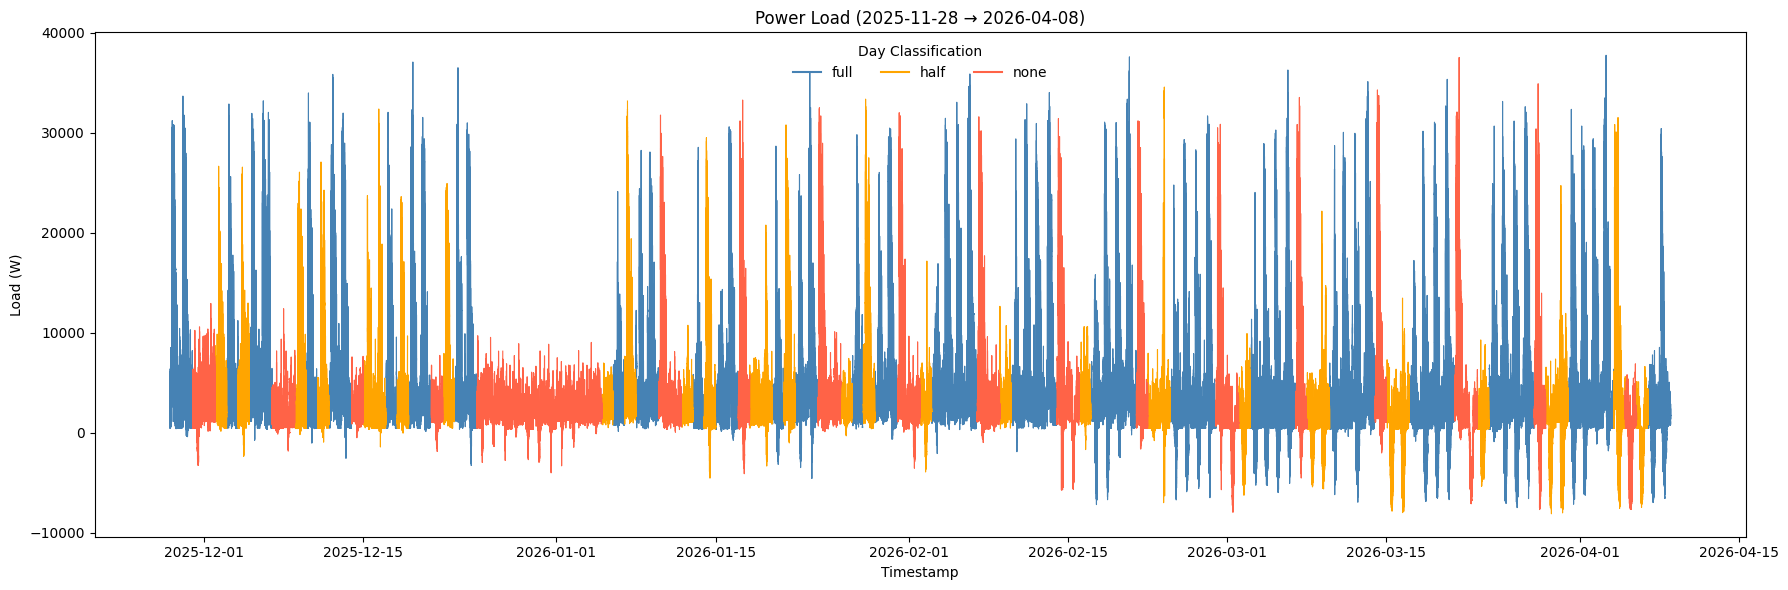

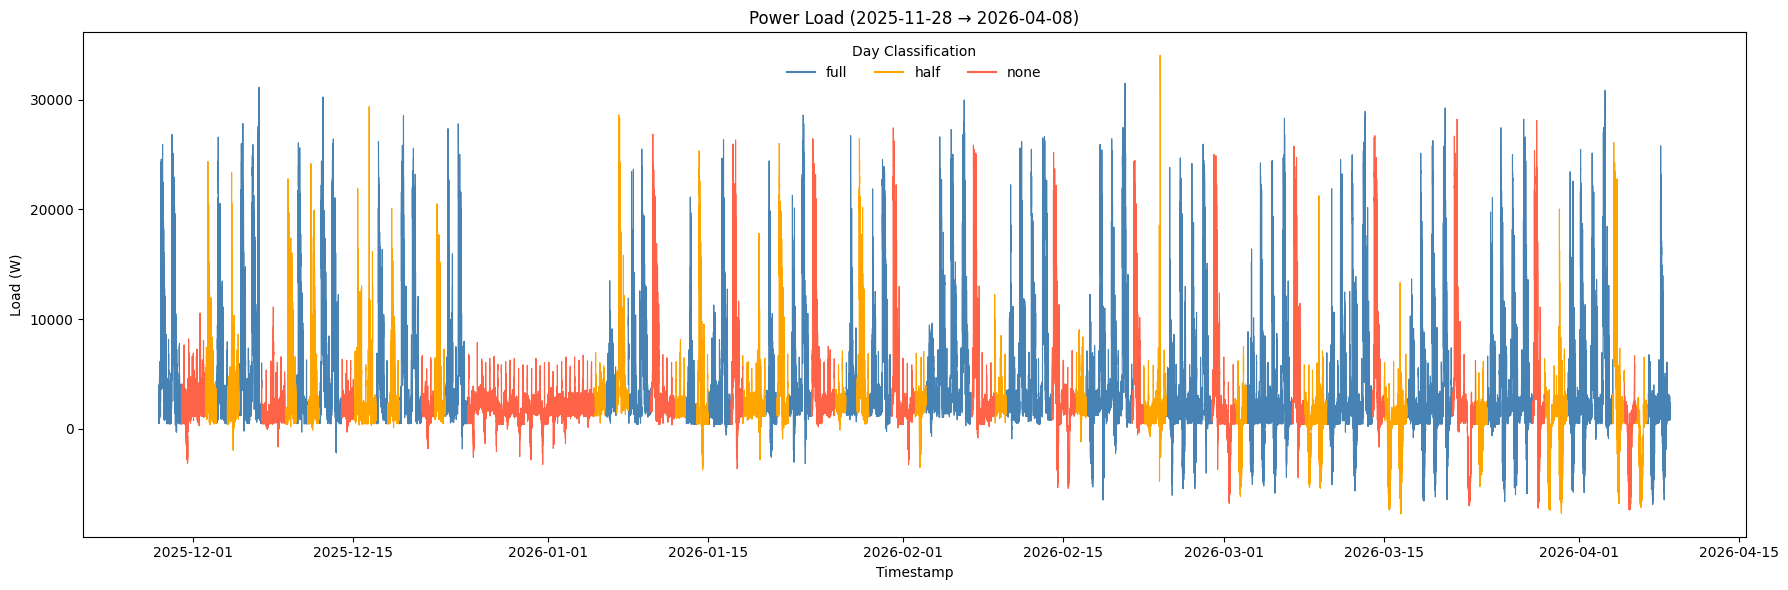

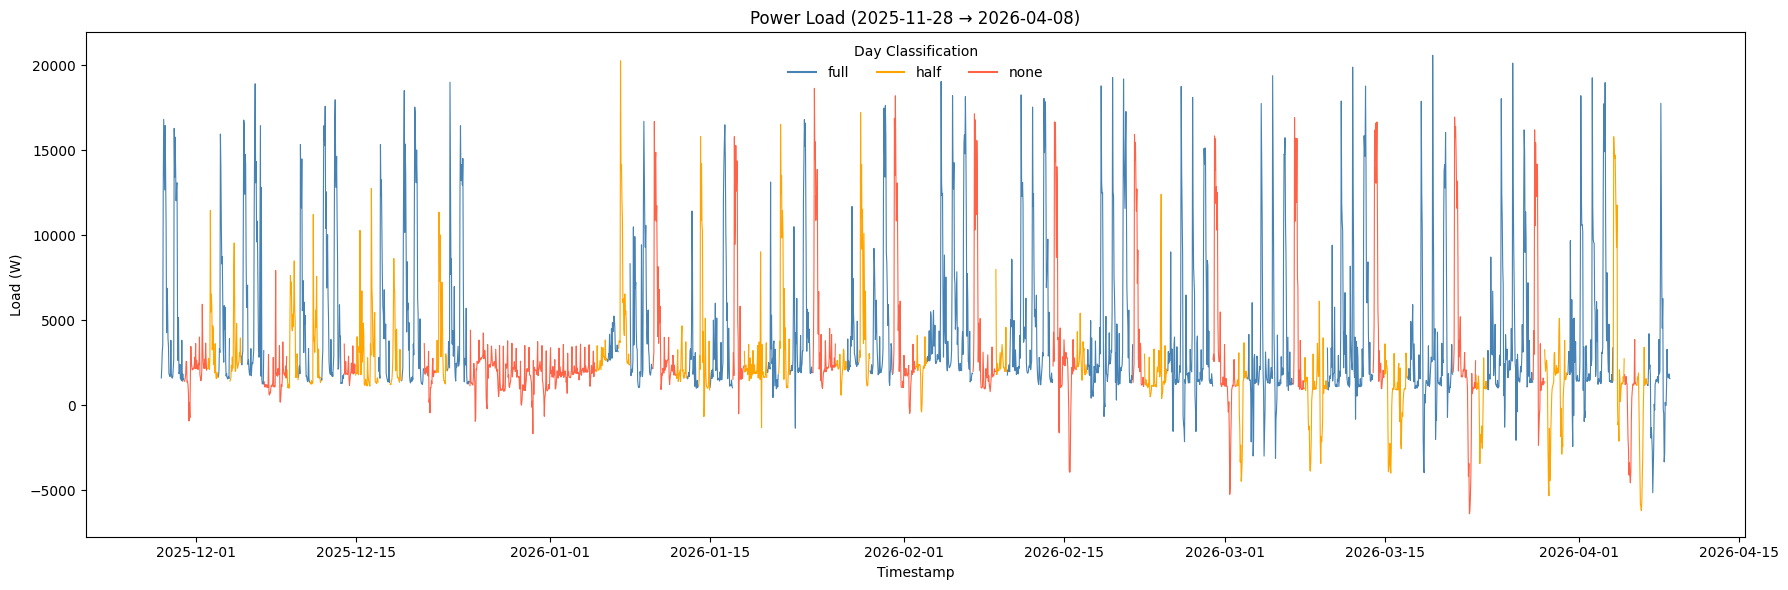

In [53]:
plot_timeseries_load(df_raw)
plot_timeseries_load(df_1min)
plot_timeseries_load(df_1h)

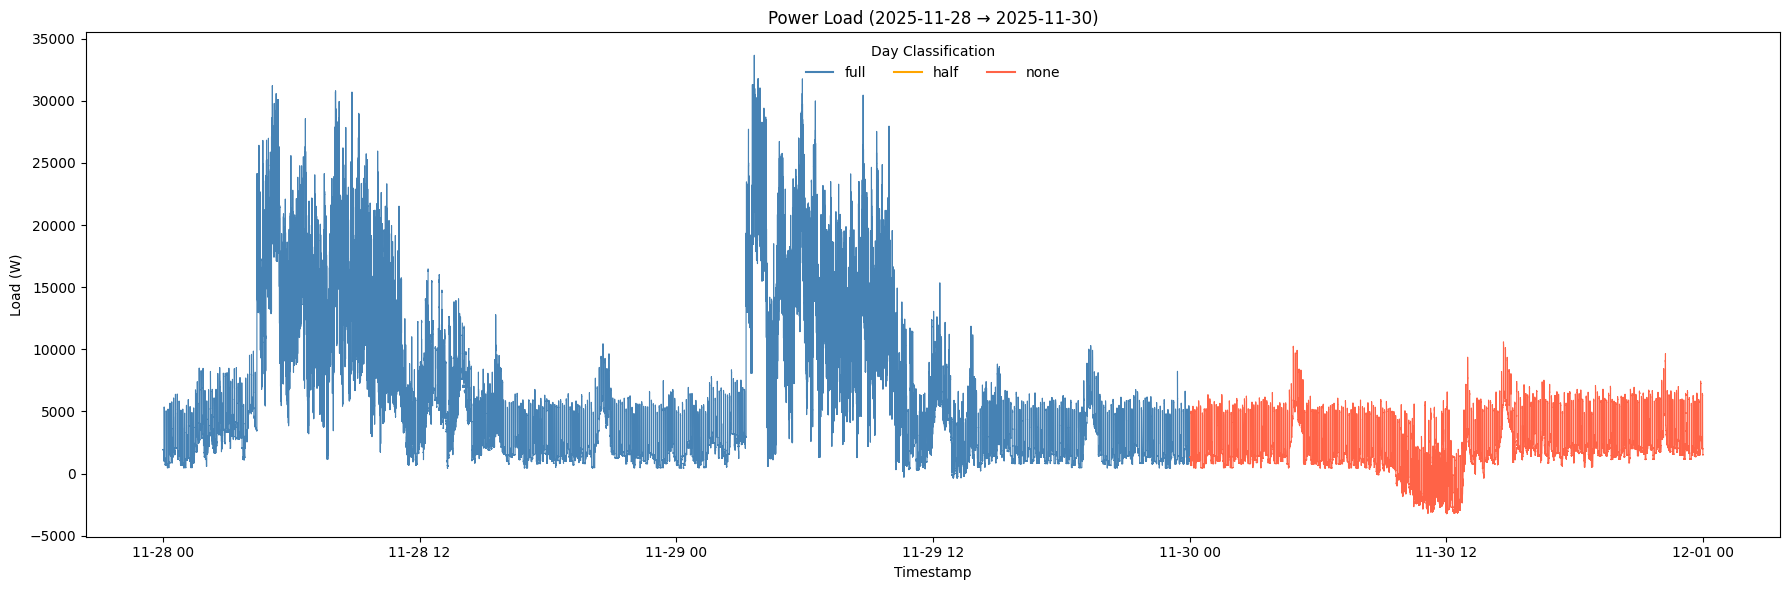

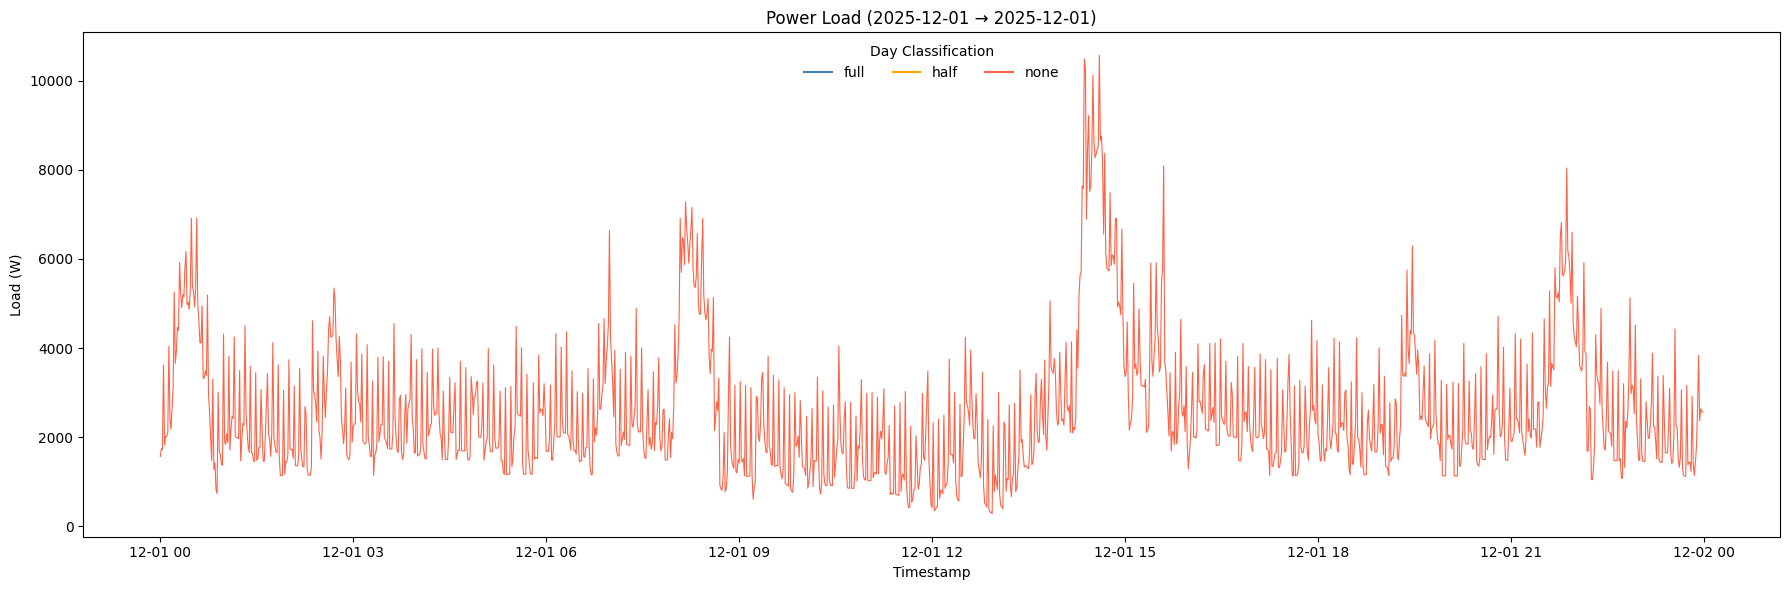

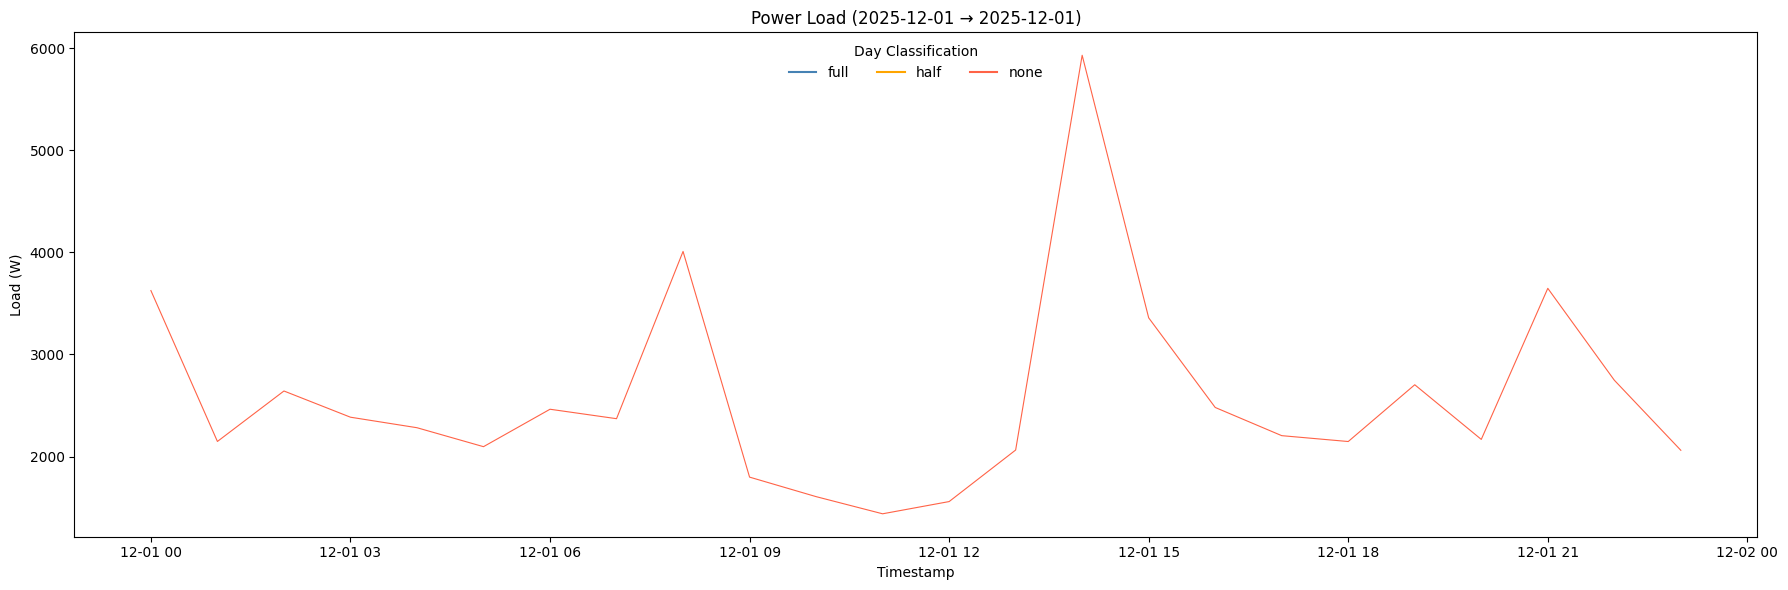

In [54]:
plot_timeseries_load(df_raw, start_date='2025-11-28', end_date='2025-11-30')
plot_timeseries_load(df_1min, start_date='2025-12-01', end_date='2025-12-01')
plot_timeseries_load(df_1h, start_date='2025-12-01', end_date='2025-12-01')

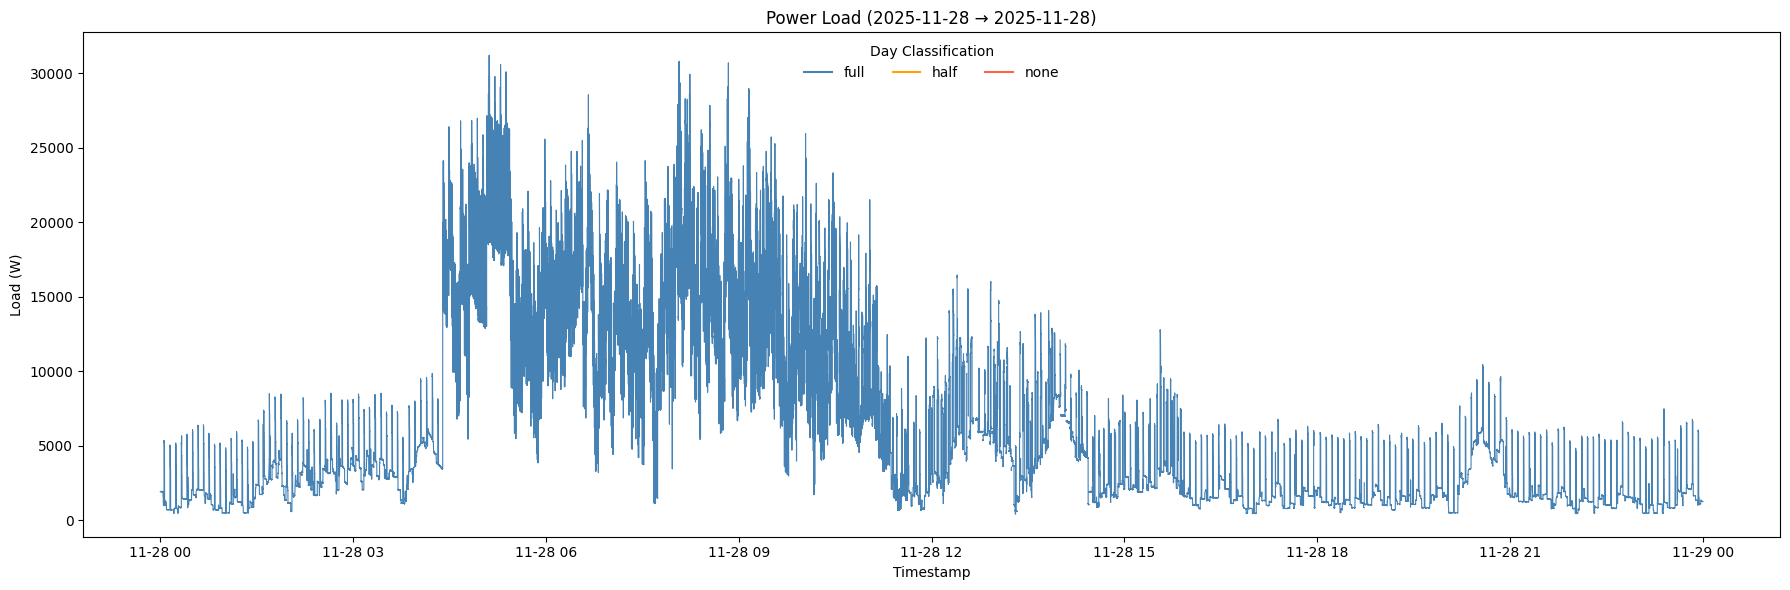

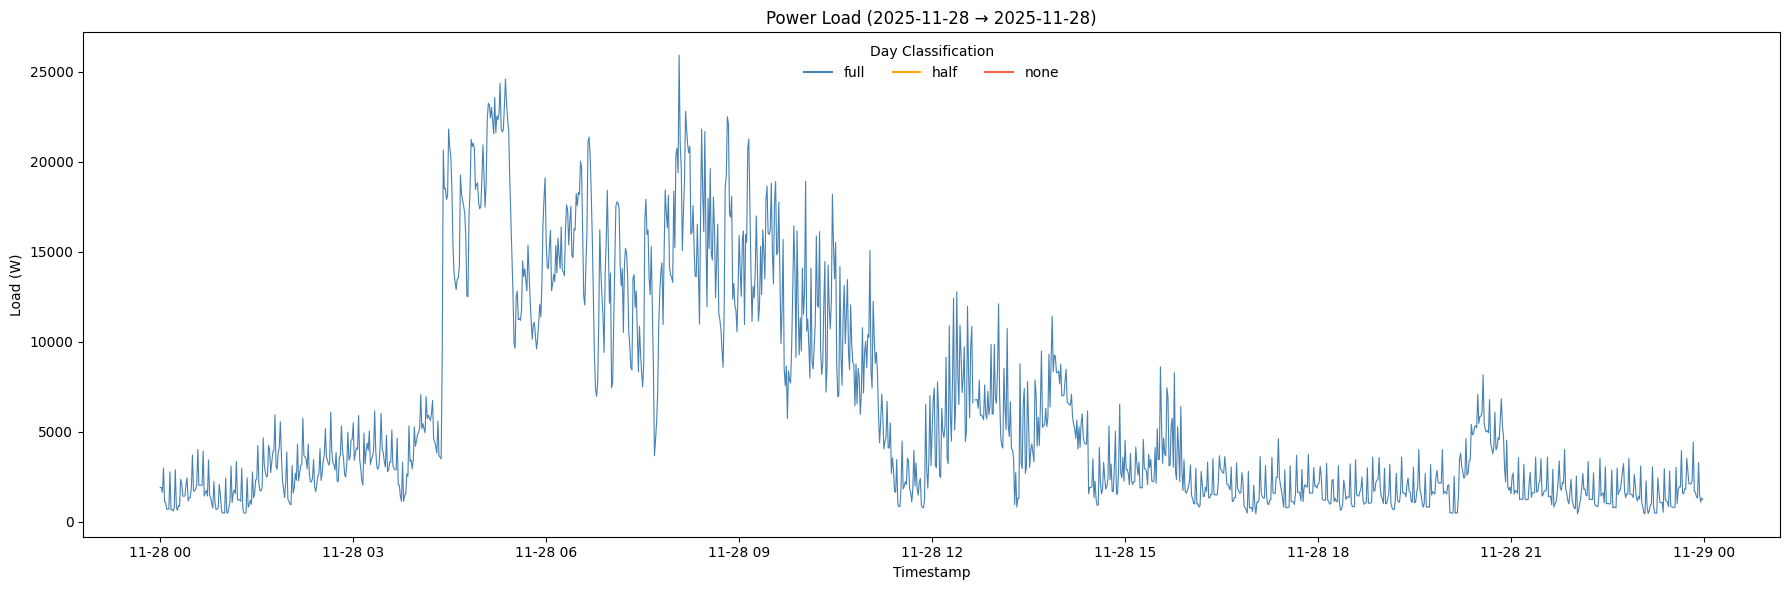

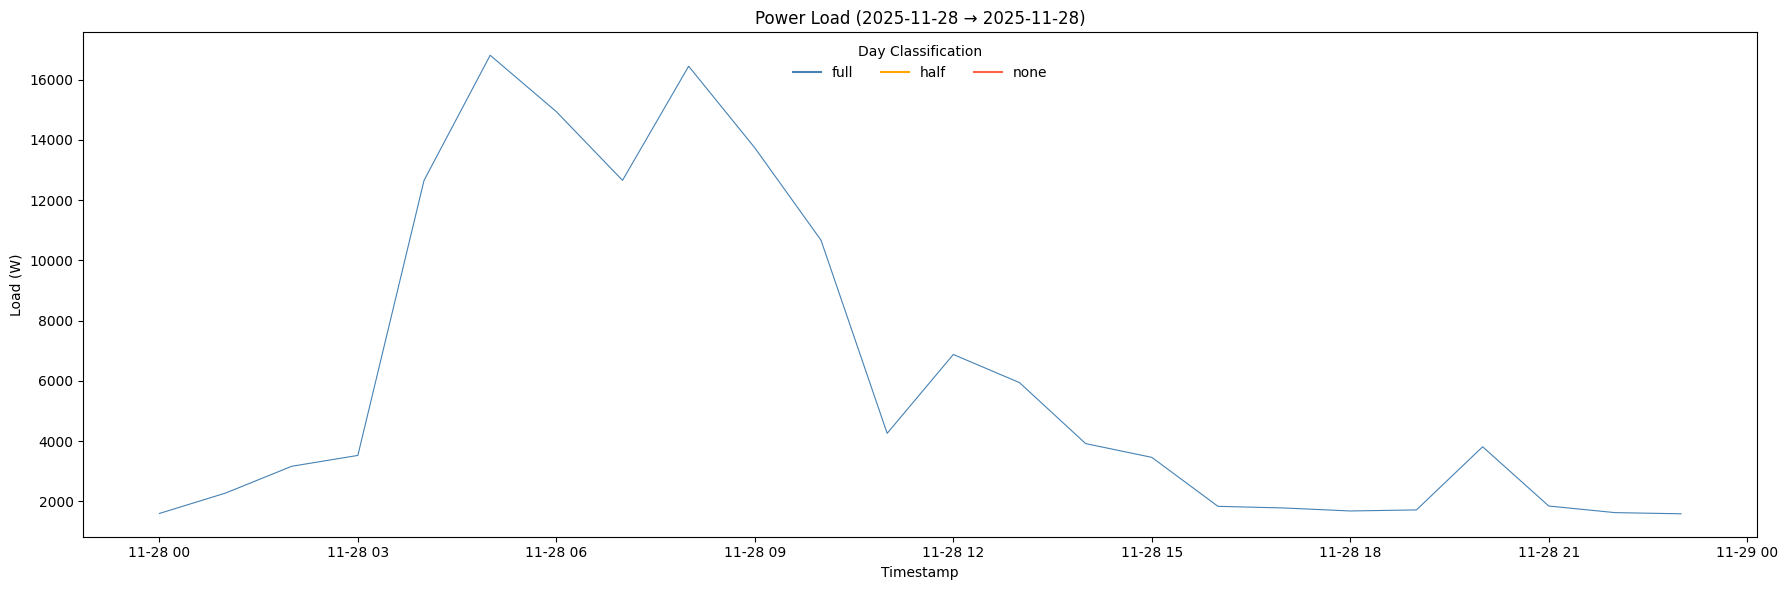

In [55]:
date = '2025-11-28'

plot_timeseries_load(df_raw, start_date=date, end_date=date)
plot_timeseries_load(df_1min, start_date=date, end_date=date)
plot_timeseries_load(df_1h, start_date=date, end_date=date)

#### Missing Values

Missing values (raw 1-second resolution):
--------------------------------------------------
           missing      %
load         46099  0.404
day_class        0  0.000
--------------------------------------------------


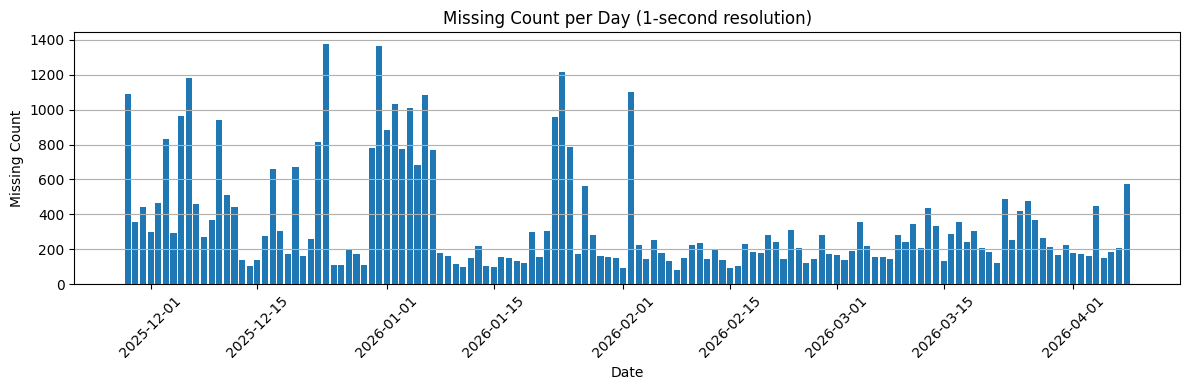

In [56]:
print(f"Missing values (raw 1-second resolution):")
print("--------------------------------------------------")
total = len(df_raw)
missing = df_raw.isnull().sum()
pct = ((missing / total) * 100).round(3)
print(pd.DataFrame({'missing': missing, '%': pct}))
print("--------------------------------------------------")

missing_per_day = df_raw["load"].isna().resample("D").sum()
plt.figure(figsize=(12, 4))
plt.bar(missing_per_day.index, missing_per_day.values)
plt.title("Missing Count per Day (1-second resolution)")
plt.xlabel("Date")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Zero Load

Zero Load Values (raw 1-second resolution):
--------------------------------------------------
   count      %
0    261  0.002
--------------------------------------------------


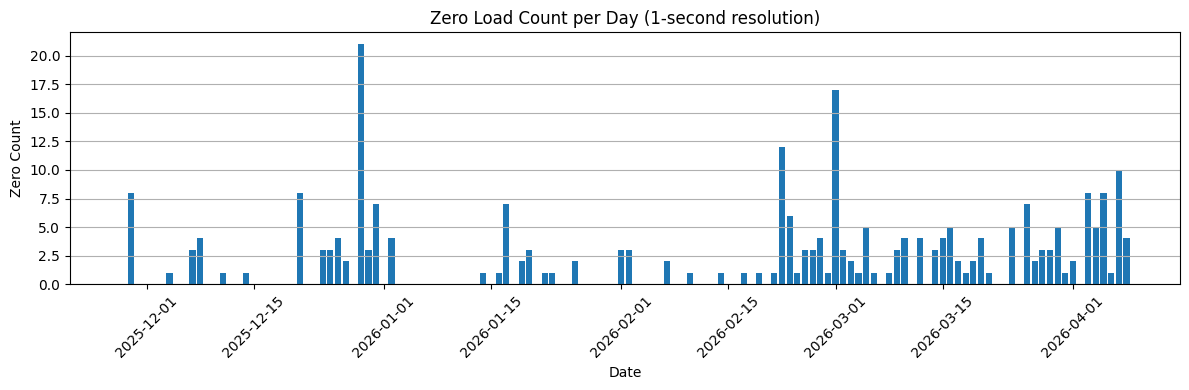

In [57]:
# ── RAW (1-second) ───────────────────────────────────────────────────────────
print("Zero Load Values (raw 1-second resolution):")
print("--------------------------------------------------")

total = len(df_raw)
zero = (df_raw["load"] == 0).sum()
pct = round((zero / total) * 100, 3)

print(pd.DataFrame({'count': [zero], '%': [pct]}))
print("--------------------------------------------------")

# Zero per day (count)
zero_per_day = (df_raw["load"] == 0).resample("D").sum()

plt.figure(figsize=(12, 4))
plt.bar(zero_per_day.index, zero_per_day.values)
plt.title("Zero Load Count per Day (1-second resolution)")
plt.xlabel("Date")
plt.ylabel("Zero Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Negative Load

Negative Load Values (raw 1-second resolution):
--------------------------------------------------
    count      %
0  703079  6.165
--------------------------------------------------


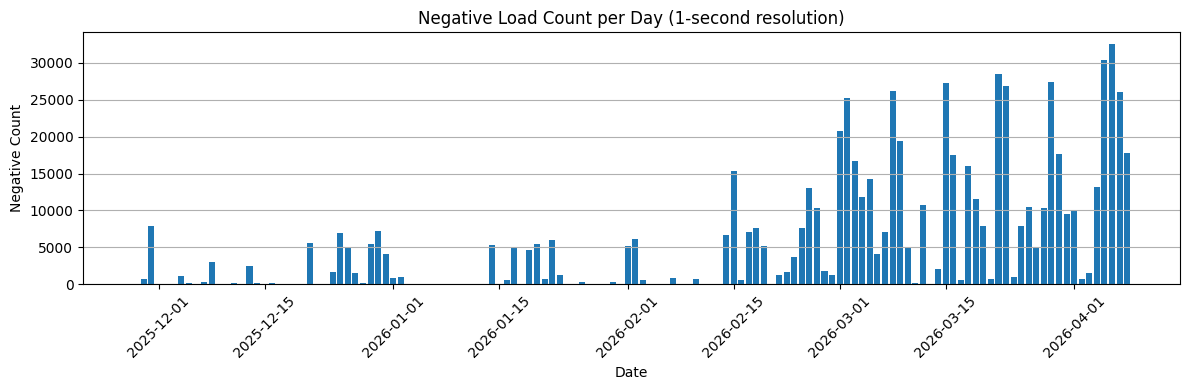

In [58]:
print("Negative Load Values (raw 1-second resolution):")
print("--------------------------------------------------")

total = len(df_raw)
negative = (df_raw["load"] < 0).sum()
pct = round((negative / total) * 100, 3)

print(pd.DataFrame({'count': [negative], '%': [pct]}))
print("--------------------------------------------------")


# ── Negative per day (count) ────────────────────────────────────────────────
neg_per_day = (df_raw["load"] < 0).resample("D").sum()

plt.figure(figsize=(12, 4))
plt.bar(neg_per_day.index, neg_per_day.values)

plt.title("Negative Load Count per Day (1-second resolution)")
plt.xlabel("Date")
plt.ylabel("Negative Count")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()


#### Outliers

Outliers (outside 1st–99th percentile):
-----------------------------------------
        threshold   count      %
lower  < -4760.0W  113509  0.995
upper  > 22847.0W  113566  0.996


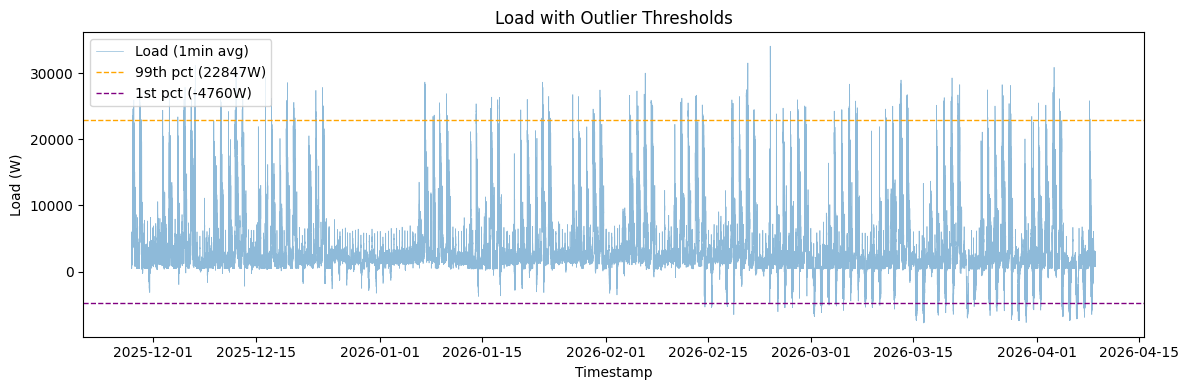

In [59]:
# ── Outlier Detection ────────────────────────────────────────────────────────
q01 = df_raw["load"].quantile(0.01)
q99 = df_raw["load"].quantile(0.99)

lower_outliers = df_raw["load"] < q01
upper_outliers = df_raw["load"] > q99

print(f"Outliers (outside 1st–99th percentile):")
print("-----------------------------------------")
print(pd.DataFrame({
    "threshold": [f"< {q01:.1f}W", f"> {q99:.1f}W"],
    "count":     [lower_outliers.sum(), upper_outliers.sum()],
    "%":         [round(lower_outliers.mean() * 100, 3), round(upper_outliers.mean() * 100, 3)]
}, index=["lower", "upper"]))

# ── Plot (downsampled for speed) ──────────────────────────────────────────────
sample = df_raw["load"].resample("1min").mean()  # downsample to 1-min for plotting

plt.figure(figsize=(12, 4))
plt.plot(sample.index, sample.values, linewidth=0.5, alpha=0.5, label="Load (1min avg)")
plt.axhline(q99, color="orange", linestyle="--", linewidth=1, label=f"99th pct ({q99:.0f}W)")
plt.axhline(q01, color="purple", linestyle="--", linewidth=1, label=f"1st pct ({q01:.0f}W)")
plt.title("Load with Outlier Thresholds")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend()
plt.tight_layout()
plt.show()

#### Load Distribution

In [60]:
# Use 1 min resolution for
df = df_1min

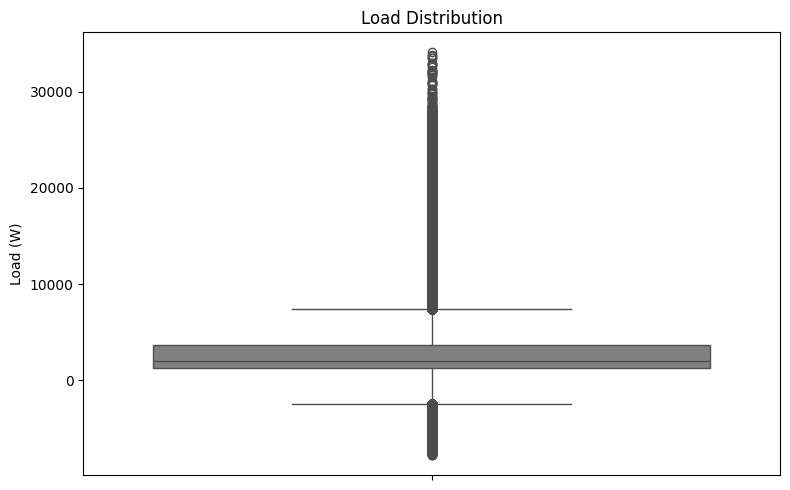

Load Stats:


,count,mean,std,min,25%,50%,75%,max
load,190006.0,3511.08,4722.73,-7742.17,1265.94,2035.79,3726.95,34057.93


In [61]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='load', color='grey')
plt.title("Load Distribution")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("Load Stats:")
display(df['load'].describe().round(2).to_frame().T)

##### By day class

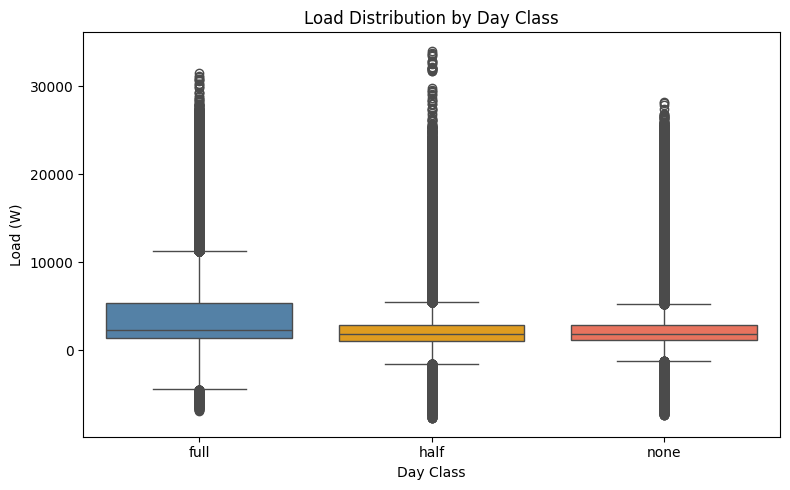


Load Stats By Class:


,count,mean,std,min,25%,50%,75%,max
day_class,,,,,,,,
full,90669.0,4372.72,5263.11,-6894.20,1423.88,2337.45,5350.23,31515.92
half,46058.0,2419.89,3656.85,-7742.17,1066.12,1810.54,2828.93,34057.93
none,53279.0,2988.07,4275.11,-7387.52,1195.92,1866.52,2831.40,28240.05


In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day_class', y='load', hue='day_class', palette=color_map,
            order=['full', 'half', 'none'], legend=False)
plt.title("Load Distribution by Day Class")
plt.xlabel("Day Class")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("\nLoad Stats By Class:")
display(df.groupby('day_class')['load'].describe().round(2))

##### By month

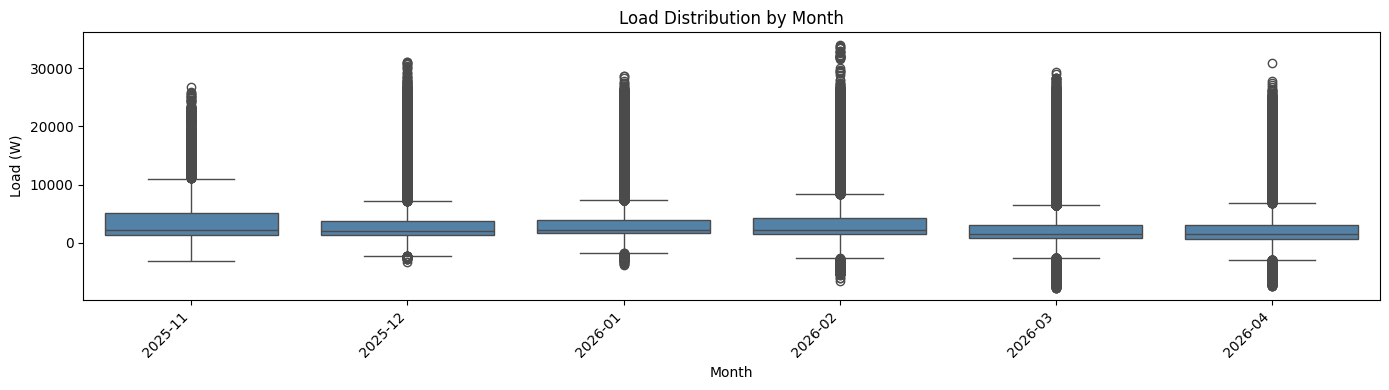

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11,4319.0,4539.46,5408.05,-3156.72,1281.70,2257.82,5187.62,26838.28
2025-12,44601.0,3584.11,4267.97,-3254.73,1345.05,2063.42,3705.00,31137.08
2026-01,44639.0,3815.12,4242.19,-3740.50,1633.62,2286.30,3915.40,28626.30
2026-02,40306.0,4023.51,4944.10,-6496.05,1480.21,2264.73,4256.33,34057.93
2026-03,44627.0,2765.74,4977.96,-7742.17,761.02,1560.60,3031.43,29257.95
2026-04,11514.0,2758.79,5545.13,-7387.52,702.09,1497.47,3139.00,30861.03


In [63]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.to_period('M').astype(str), y='load', color='steelblue')
plt.title("Load Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby(df.index.to_period('M'))['load'].describe().round(2))

##### By day

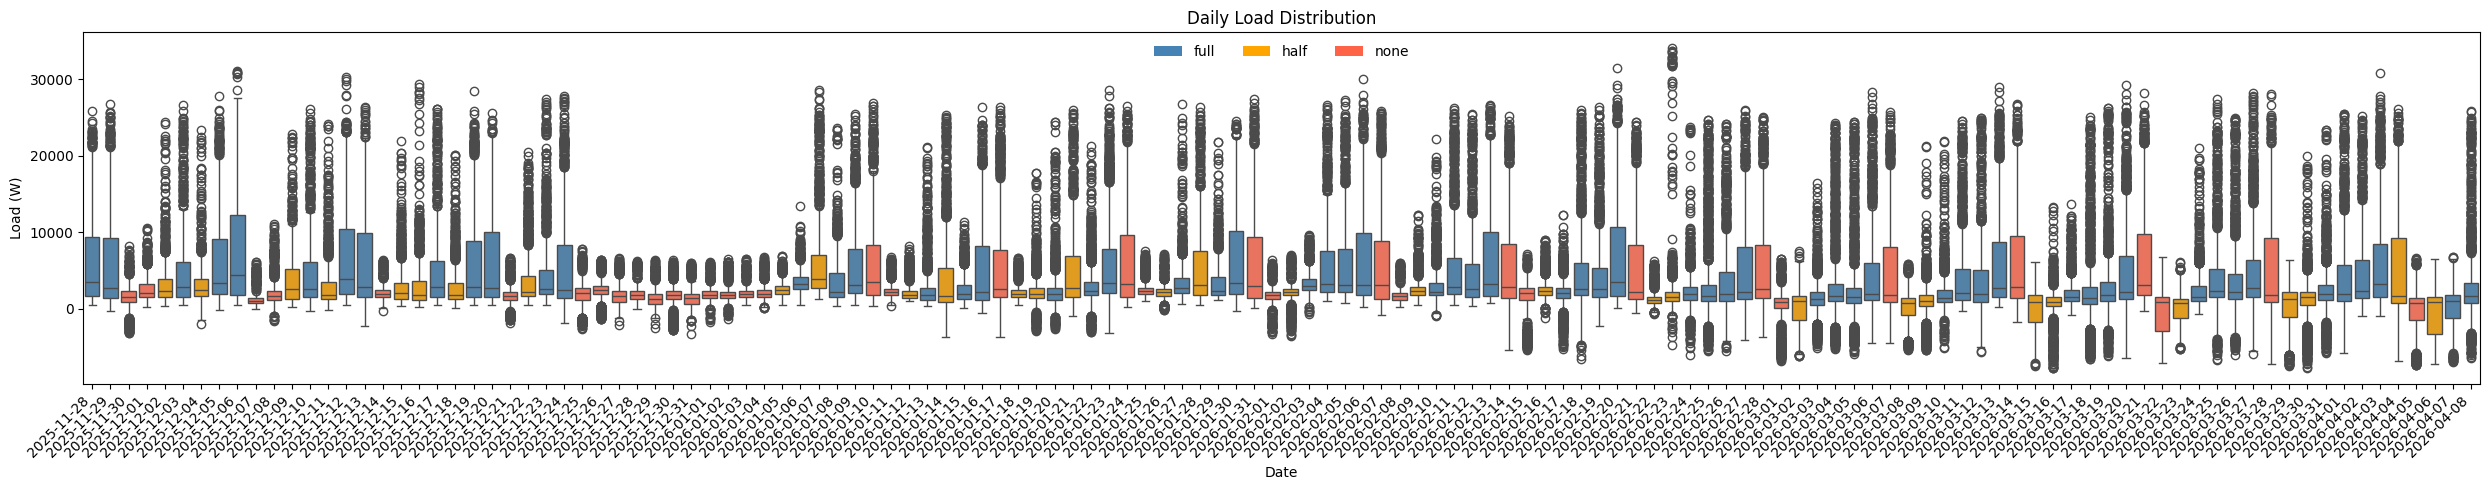

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11-28,1439.0,6200.92,5909.77,447.93,1684.22,3500.98,9455.06,25916.90
2025-11-29,1440.0,5748.48,6167.23,-308.64,1369.02,2774.97,9241.31,26838.28
2025-11-30,1440.0,1670.13,1537.39,-3156.72,947.40,1592.38,2395.70,8205.80
2025-12-01,1440.0,2579.47,1510.34,284.43,1548.58,2126.93,3261.06,10566.67
2025-12-02,1439.0,3313.73,3036.05,357.53,1576.91,2323.83,3886.12,24374.62
...,...,...,...,...,...,...,...,...
2026-04-04,1437.0,4883.72,6890.36,-6821.92,793.98,1646.00,9255.35,26110.82
2026-04-05,1440.0,-186.46,2617.58,-7387.52,-1487.85,813.23,1393.45,6684.62
2026-04-06,1440.0,-698.57,3104.82,-7154.53,-3283.65,893.19,1488.33,6553.20


In [64]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df, x=df.index.normalize(), y='load',
            hue=df['day_class'], palette=color_map, legend=False)
plt.title("Daily Load Distribution")
plt.xlabel("Date")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')

handles = [Patch(facecolor=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

display(df.groupby(df.index.normalize())['load'].describe().round(2))

##### By day of week

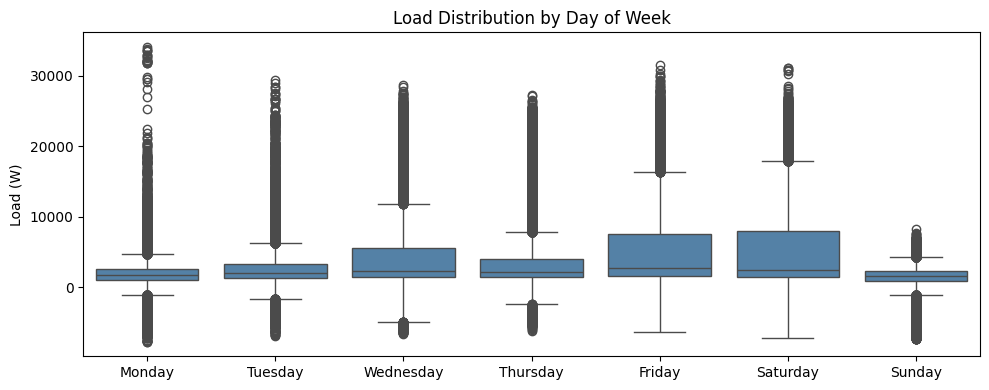

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
Monday,27344.0,1823.15,2574.78,-7742.17,1063.51,1768.60,2500.17,34057.93
Tuesday,27350.0,2689.61,2999.30,-6894.20,1288.05,2039.52,3255.11,29371.43
Wednesday,27331.0,4365.84,5403.12,-6644.41,1354.15,2309.05,5545.81,28626.30
Thursday,25918.0,3478.52,4206.85,-6210.00,1371.26,2124.78,3922.15,27290.02
Friday,27351.0,5523.30,5913.75,-6455.12,1621.23,2723.65,7519.20,31515.92
Saturday,27352.0,5412.24,6121.53,-7232.90,1368.23,2458.97,7960.20,31137.08
Sunday,27360.0,1284.03,2014.12,-7417.85,879.04,1575.97,2206.50,8205.80


In [65]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x=df.index.day_name(), y='load', order=days_order, color='steelblue')
plt.title("Load Distribution by Day of Week")
plt.xlabel("")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.day_name())['load'].describe().round(2).reindex(days_order))

#### By hour

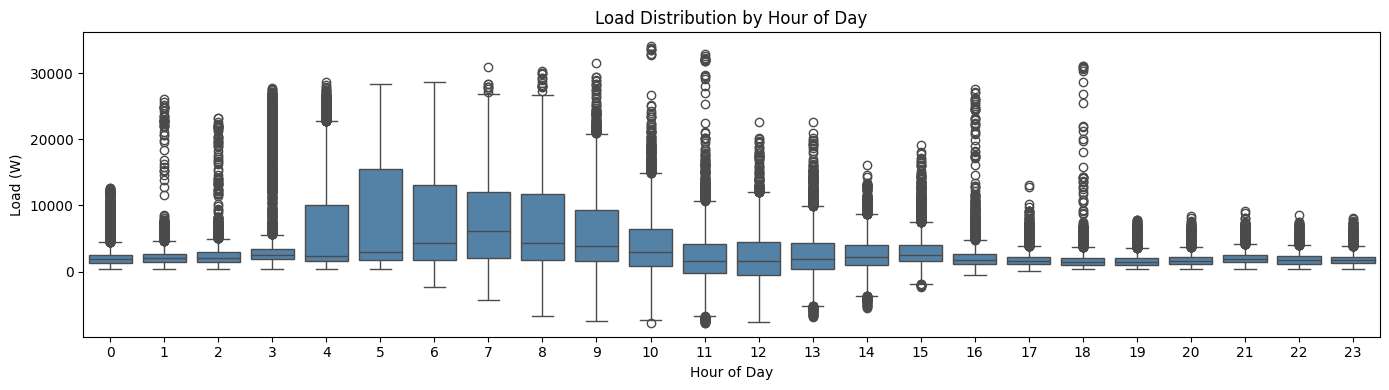

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,7920.0,2264.95,1687.11,402.60,1305.88,1843.79,2559.04,12588.13
1,7919.0,2368.10,1972.12,401.70,1386.30,1988.37,2707.35,26110.82
2,7919.0,2444.30,1802.01,397.63,1520.72,2130.68,2913.38,23202.29
3,7920.0,4430.74,5741.62,404.93,1877.03,2479.62,3374.63,27808.30
4,7919.0,6464.58,7394.09,404.53,1643.58,2347.87,10083.17,28626.30
5,7916.0,8432.86,7992.82,454.13,1815.48,2981.30,15513.10,28318.14
6,7920.0,7562.32,6666.38,-2334.33,1830.45,4324.76,13075.08,28613.97
7,7896.0,7268.36,6151.34,-4289.30,2076.17,6096.07,11981.96,30861.03
8,7915.0,6608.65,6752.03,-6699.83,1742.97,4299.65,11711.28,30258.63


In [66]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.hour, y='load', color='steelblue')
plt.title("Load Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.hour)['load'].describe().round(2))

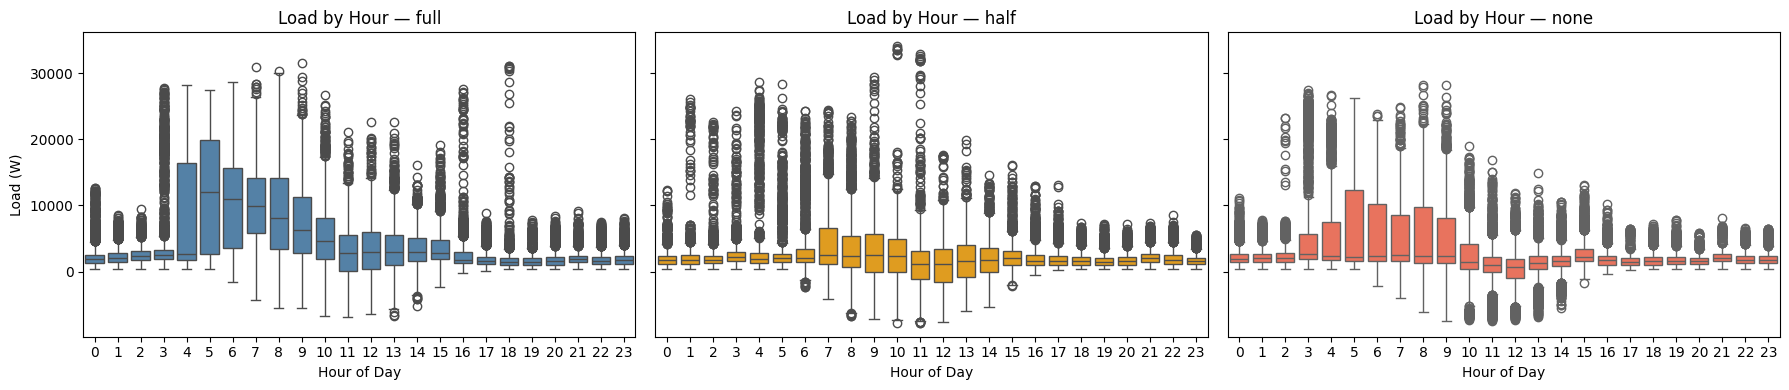


full:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,3780.0,2335.95,1827.14,405.67,1316.82,1885.65,2585.50,12588.13
1,3779.0,2389.10,1442.15,401.70,1478.38,2066.27,2829.42,8551.65
2,3780.0,2521.31,1160.64,397.63,1735.70,2352.09,3116.53,9480.60
3,3780.0,3800.70,4504.89,408.25,1955.79,2534.83,3339.40,27808.30
4,3780.0,8125.52,8189.52,425.08,1769.03,2683.82,16400.17,28236.73
5,3780.0,12157.96,8202.85,470.77,2662.99,12085.40,19909.56,27481.68
6,3780.0,10549.90,6557.65,-1615.30,3621.81,10923.42,15613.80,28613.97
7,3756.0,10101.74,5744.25,-4289.30,5816.39,9976.05,14112.96,30861.03
8,3775.0,8968.08,6667.77,-5516.45,3399.58,8117.93,14078.74,30258.63



half:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,1920.0,2047.61,1522.18,402.63,1137.82,1708.22,2351.60,12268.62
1,1920.0,2393.77,3127.78,402.63,1190.28,1727.89,2450.42,26110.82
2,1919.0,2316.12,2639.37,404.35,1247.00,1752.91,2409.52,22653.37
3,1920.0,2830.79,2561.47,404.93,1624.53,2215.62,2964.14,24249.29
4,1919.0,4244.17,6309.27,404.53,1342.83,1973.40,2828.26,28626.30
5,1917.0,3497.99,4371.05,454.13,1513.08,1999.63,2670.07,28318.14
6,1920.0,3913.00,4814.20,-2334.33,1434.49,2000.87,3429.37,24287.47
7,1920.0,4243.27,5186.57,-4208.17,1222.14,2444.94,6647.59,24374.62
8,1920.0,3461.23,5613.22,-6699.83,752.23,2389.02,5448.13,23376.40



none:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,2220.0,2332.02,1553.93,402.60,1388.22,1892.79,2653.61,11108.47
1,2220.0,2310.14,1368.16,403.10,1434.14,2023.89,2715.50,7873.72
2,2220.0,2423.99,1801.91,414.25,1491.03,2092.38,2816.86,23202.29
3,2220.0,6887.24,8275.50,434.83,1975.39,2588.23,5705.26,27438.20
4,2220.0,5555.87,6055.74,452.85,1699.38,2381.34,7472.68,26730.43
5,2219.0,6350.50,6913.33,461.27,1596.95,2236.20,12370.14,26240.38
6,2220.0,5631.52,5904.36,-2159.05,1622.88,2416.98,10179.81,23865.92
7,2220.0,5090.90,5410.81,-4021.72,1580.27,2476.22,8494.77,24905.65
8,2220.0,5318.64,6326.54,-6138.77,1379.02,2304.29,9784.82,28120.32


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, cls in zip(axes, ['full', 'half', 'none']):
    mask = df['day_class'] == cls
    sns.boxplot(data=df[mask], x=df[mask].index.hour, y='load',
                color=color_map[cls], ax=ax)
    ax.set_title(f"Load by Hour — {cls}")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (W)" if ax == axes[0] else "")

plt.tight_layout()
plt.show()

for cls in ['full', 'half', 'none']:
    mask = df['day_class'] == cls
    print(f"\n{cls}:")
    display(df[mask].groupby(df[mask].index.hour)['load'].describe().round(2))

## Step 2: Data Cleaning

### Clean Data

Adding flag columns for data quality issues without altering original load values (used in preprocessing to filter rows before modeling):

- `is_missing`: Load value is `NaN` — sensor did not record a value
- `is_zero`: Load value is exactly `0` — either everything is off or solar perfectly offsets consumption
- `is_negative`: Load value is `< 0` — solar production exceeds consumption, surplus sent to grid
- `is_high_outlier`: Load value exceeds the 99th percentile — unusually high consumption reading
- `is_low_outlier`: Load value is below the 1st percentile — unusually low or negative reading

In [68]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flag data quality issues without altering original load values.
    Adds boolean flag columns for missing, zero, and outlier load values.
    """
    df = df.copy()

    # Flags
    df["is_missing"]      = df["load"].isna()
    df["is_zero"]         = df["load"] == 0
    df["is_negative"]     = df["load"] < 0
    df["is_low_outlier"]  = df["load"] < df["load"].quantile(0.01)
    df["is_high_outlier"] = df["load"] > df["load"].quantile(0.99)

    # Summary
    total = len(df)
    for col in ["is_missing", "is_zero", "is_negative", "is_low_outlier", "is_high_outlier"]:
        count = df[col].sum()
        pct   = count / total * 100
        print(f"  {col:15s}: {count:>7,} ({pct:.2f}%)")

    return df

# Run
df_clean = clean_data(df_raw)
df_clean.head()

  is_missing     :  46,099 (0.40%)
  is_zero        :     261 (0.00%)
  is_negative    : 703,079 (6.16%)
  is_low_outlier : 113,509 (1.00%)
  is_high_outlier: 113,566 (1.00%)


,load,day_class,is_missing,is_zero,is_negative,is_low_outlier,is_high_outlier
timestamp,,,,,,,
2025-11-28 00:00:00,1925.0,full,False,False,False,False,False
2025-11-28 00:00:01,1922.0,full,False,False,False,False,False
2025-11-28 00:00:02,1921.0,full,False,False,False,False,False
2025-11-28 00:00:03,1921.0,full,False,False,False,False,False
2025-11-28 00:00:04,1926.0,full,False,False,False,False,False


### Save Data

In [69]:
save_clean(df_clean)

✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/002_clean/load.parquet


## Step 3: Downsample

### Downsample Data
The raw 1-second data is downsampled to lower resolutions by **averaging load per interval**. This reduces noise, speeds up feature engineering and modeling, and better matches the forecast horizons. Quality flags are recomputed at each resolution.

Resolutions: `1min`, `5min`, `10min`, `15min`, `30min`, `1h`

In [70]:
def downsample(df: pd.DataFrame, resolution: str) -> pd.DataFrame:
    """
    Downsample to target resolution by averaging load per interval.
    Reattaches day_class and recomputes quality flags at new resolution.
    """

    # Downsample load
    df_resampled = df["load"].resample(resolution).mean().to_frame()
    print(f"  shape: {df_resampled.shape}")

    # Re-attach day_class
    day_class_map = df.groupby(df.index.date)["day_class"].first()
    df_resampled["day_class"] = pd.Series(df_resampled.index.date, index=df_resampled.index).map(day_class_map)

    # Recompute flags using clean_data
    df_resampled = clean_data(df_resampled)

    return df_resampled


# ── RUN ───────────────────────────────────────────────────────────────────────
RESOLUTIONS = ["1min", "5min", "10min", "15min", "30min", "1h"]

dfs_downsampled = {}
for res in RESOLUTIONS:
    print(f"\n── {res} ──────────────────────")
    dfs_downsampled[res] = downsample(df_clean, res)


── 1min ──────────────────────
  shape: (190080, 1)
  is_missing     :      74 (0.04%)
  is_zero        :       0 (0.00%)
  is_negative    :  11,340 (5.97%)
  is_low_outlier :   1,901 (1.00%)
  is_high_outlier:   1,901 (1.00%)

── 5min ──────────────────────
  shape: (38016, 1)
  is_missing     :       3 (0.01%)
  is_zero        :       0 (0.00%)
  is_negative    :   2,214 (5.82%)
  is_low_outlier :     381 (1.00%)
  is_high_outlier:     381 (1.00%)

── 10min ──────────────────────
  shape: (19008, 1)
  is_missing     :       1 (0.01%)
  is_zero        :       0 (0.00%)
  is_negative    :   1,081 (5.69%)
  is_low_outlier :     191 (1.00%)
  is_high_outlier:     191 (1.00%)

── 15min ──────────────────────
  shape: (12672, 1)
  is_missing     :       0 (0.00%)
  is_zero        :       0 (0.00%)
  is_negative    :     718 (5.67%)
  is_low_outlier :     127 (1.00%)
  is_high_outlier:     127 (1.00%)

── 30min ──────────────────────
  shape: (6336, 1)
  is_missing     :       0 (0.00%)
  

### Save Data

In [71]:
for res, df in dfs_downsampled.items():
  save_downsampled(df, res)

✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/1min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/5min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/10min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/15min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/30min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/1h_load.parquet


## Step 4: Feature Engineering

Features are created at each target resolution after downsampling. Relevant features are selected per model and forecast horizon downstream.

### Feature Descriptions

#### Time Features

Raw calendar components extracted from the timestamp. Captures the position of each reading in time.

| Feature | Description |
|---------|-------------|
| `minute` | Minute of the hour (0–59) |
| `hour` | Hour of the day (0–23) |
| `day` | Day of the month (1–31) |
| `dayofweek` | Day of the week (0=Monday, 6=Sunday) |
| `dayofyear` | Day of the year (1–365) |
| `month` | Month of the year (1–12) |
| `is_weekend` | 1 if Saturday or Sunday, 0 otherwise |

#### Cyclical Encoding

Sine/cosine transformations of time features so the model understands that 11pm and midnight are close, and January and December are close.

| Feature | Description |
|---------|-------------|
| `hour_sin`, `hour_cos` | Cyclical encoding of hour (cycle = 24hrs) |
| `min_sin`, `min_cos` | Cyclical encoding of minute (cycle = 60min) |
| `dow_sin`, `dow_cos` | Cyclical encoding of day of week (cycle = 7 days) |
| `month_sin`, `month_cos` | Cyclical encoding of month (cycle = 12 months) |
| `doy_sin`, `doy_cos` | Cyclical encoding of day of year (cycle = 365 days) |

#### Solar Proxy Features

Time-based approximations of solar PV activity, relevant because the dataset includes net load (consumption minus solar production).

| Feature | Description |
|---------|-------------|
| `solar_angle` | Cosine of time relative to solar noon — peaks at 12pm, minimum at midnight |
| `is_daylight` | 1 if between 7am–7pm when solar production is possible, 0 otherwise |

#### Lag Features

Load value at a specific point in the past. Captures the direct influence of recent and historical load on current load.

| Feature | Description |
|---------|-------------|
| `lag_X` | Load value exactly X ago |

Computed windows vary by resolution:

| Resolution | Lag Windows |
|------------|-------------|
| `1min` | 1min, 2min, 3min, 5min, 10min, 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `5min` | 5min, 10min, 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `10min` | 10min, 20min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `15min` | 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `30min` | 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `1h` | 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |

#### Rolling Features

Summary statistics over a sliding window of past load values. Captures recent level, volatility, and range.

| Feature | Description |
|---------|-------------|
| `roll_mean_X` | Average load over the past X window |
| `roll_std_X` | Standard deviation of load over the past X window |
| `roll_max_X` | Maximum load over the past X window |
| `roll_min_X` | Minimum load over the past X window |

Computed windows vary by resolution:

| Resolution | Windows |
|------------|---------|
| `1min` | 5min, 15min, 30min, 1hr, 3hr, 6hr |
| `5min` | 15min, 30min, 1hr, 3hr, 6hr |
| `10min` | 30min, 1hr, 3hr, 6hr |
| `15min` | 30min, 1hr, 3hr, 6hr |
| `30min` | 1hr, 3hr, 6hr |
| `1h` | 3hr, 6hr, 12hr |

#### Trend Features

Captures the direction and magnitude of load change over recent windows.

| Feature | Description |
|---------|-------------|
| `delta_X` | Difference between load 1 interval ago and load X ago |
| `slope_X` | Linear rate of change estimated over a rolling window of X |

Delta computed for same windows as rolling features. Slope computed for:

| Resolution | Slope Windows |
|------------|---------------|
| `1min` | 5min, 15min, 30min, 1hr |
| `5min` | 15min, 30min, 1hr |
| `10min` | 30min, 1hr |
| `15min` | 30min, 1hr |
| `30min` | 1hr, 3hr |
| `1h` | 3hr, 6hr |

### Create Features

In [87]:
# ── Resolution Feature Config ─────────────────────────────────────────────────
# All time values in minutes. Intervals computed inside function based on resolution.

RESOLUTION_MINUTES = {
    "1min": 1, "5min": 5, "10min": 10,
    "15min": 15, "30min": 30, "1h": 60
}

# Lag windows per resolution (in minutes)
LAG_CONFIG = {
    "1min":  [1, 2, 3, 5, 10, 15, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "5min":  [5, 10, 15, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "10min": [10, 20, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "15min": [15, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "30min": [30, 60, 120, 180, 360, 720, 1440, 10080],
    "1h":    [60, 120, 180, 360, 720, 1440, 10080],
}

# Rolling/delta/slope windows per resolution (in minutes)
WINDOW_CONFIG = {
    "1min":  [5, 15, 30, 60, 180, 360],
    "5min":  [15, 30, 60, 180, 360],
    "10min": [30, 60, 180, 360],
    "15min": [30, 60, 180, 360],
    "30min": [60, 180, 360],
    "1h":    [180, 360, 720],
}

SLOPE_CONFIG = {
    "1min":  [5, 15, 30, 60],
    "5min":  [15, 30, 60],
    "10min": [30, 60],
    "15min": [30, 60],
    "30min": [60, 180],
    "1h":    [180, 360],
}

def minutes_to_label(minutes: int) -> str:
    """Convert minutes to a human readable label."""
    if minutes < 60:
        return f"{minutes}min"
    elif minutes < 1440:
        return f"{minutes // 60}hr"
    elif minutes < 10080:
        return f"{minutes // 1440}day"
    else:
        return f"{minutes // 10080}week"


def create_features(df: pd.DataFrame, resolution: str = "1min") -> pd.DataFrame:
    """
    Create features at the given resolution.
    All window configs are defined outside this function in LAG_CONFIG, WINDOW_CONFIG, SLOPE_CONFIG.
    """
    df = df.copy()
    load = df["load"]
    m = RESOLUTION_MINUTES[resolution]  # minutes per interval

    # ── Time Features ─────────────────────────────────────────────────────────
    df["minute"]     = df.index.minute
    df["hour"]       = df.index.hour
    df["day"]        = df.index.day
    df["dayofweek"]  = df.index.dayofweek
    df["dayofyear"]  = df.index.dayofyear
    df["month"]      = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # ── Cyclical Encoding ─────────────────────────────────────────────────────
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
    df["min_sin"]   = np.sin(2 * np.pi * df["minute"] / 60)
    df["min_cos"]   = np.cos(2 * np.pi * df["minute"] / 60)
    df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"]   = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * df["dayofyear"] / 365)

    # ── Solar Proxy ───────────────────────────────────────────────────────────
    df["solar_angle"] = np.cos(2 * np.pi * (df["hour"] - 12) / 24)
    df["is_daylight"] = ((df["hour"] >= 7) & (df["hour"] <= 19)).astype(int)

    # ── Lag Features ──────────────────────────────────────────────────────────
    for minutes in LAG_CONFIG[resolution]:
        intervals = minutes // m
        label = minutes_to_label(minutes)
        df[f"lag_{label}"] = load.shift(intervals)

    # ── Rolling Features ──────────────────────────────────────────────────────
    for minutes in WINDOW_CONFIG[resolution]:
        window = minutes // m
        label  = minutes_to_label(minutes)
        base   = load.shift(1).rolling(window)
        df[f"roll_mean_{label}"] = base.mean()
        df[f"roll_std_{label}"]  = base.std()
        df[f"roll_max_{label}"]  = base.max()
        df[f"roll_min_{label}"]  = base.min()

    # ── Trend Features ────────────────────────────────────────────────────────
    for minutes in WINDOW_CONFIG[resolution]:
        shift = minutes // m
        label = minutes_to_label(minutes)
        df[f"delta_{label}"] = load.shift(1) - load.shift(shift)

    # ── Slope Features (vectorized) ───────────────────────────────────────────
    for minutes in SLOPE_CONFIG[resolution]:
        window = minutes // m
        label  = minutes_to_label(minutes)
        n      = window
        x      = np.arange(n)
        sum_x  = x.sum()
        sum_x2 = (x ** 2).sum()
        denom  = n * sum_x2 - sum_x ** 2
        rolled = load.shift(1).rolling(window)
        sum_y  = rolled.sum()
        sum_xy = rolled.apply(lambda y: (x * y).sum(), raw=True)
        df[f"slope_{label}"] = (n * sum_xy - sum_x * sum_y) / denom

    return df


# ── Apply to all resolutions ──────────────────────────────────────────────────
dfs_featured = {}
for res, df in dfs_downsampled.items():
    print(f"Creating features for {res}...", end=" ")
    dfs_featured[res] = create_features(df, resolution=res)
    print(f"{dfs_featured[res].shape[1]} columns, {dfs_featured[res].shape[0]:,} rows")

Creating features for 1min... 74 columns, 190,080 rows
Creating features for 5min... 65 columns, 38,016 rows
Creating features for 10min... 58 columns, 19,008 rows
Creating features for 15min... 57 columns, 12,672 rows
Creating features for 30min... 51 columns, 6,336 rows
Creating features for 1h... 50 columns, 3,168 rows


### View Features

In [88]:
for res, df in dfs_featured.items():
  print(f"{res} {dfs_featured[res].shape}")
  print("--------------------------------------------------------")
  print(df.columns)
  print("")

1min (190080, 74)
--------------------------------------------------------
Index(['load', 'day_class', 'is_missing', 'is_zero', 'is_negative',
       'is_low_outlier', 'is_high_outlier', 'minute', 'hour', 'day',
       'dayofweek', 'dayofyear', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'min_sin', 'min_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
       'doy_sin', 'doy_cos', 'solar_angle', 'is_daylight', 'lag_1min',
       'lag_2min', 'lag_3min', 'lag_5min', 'lag_10min', 'lag_15min',
       'lag_30min', 'lag_1hr', 'lag_2hr', 'lag_3hr', 'lag_6hr', 'lag_12hr',
       'lag_1day', 'lag_1week', 'roll_mean_5min', 'roll_std_5min',
       'roll_max_5min', 'roll_min_5min', 'roll_mean_15min', 'roll_std_15min',
       'roll_max_15min', 'roll_min_15min', 'roll_mean_30min', 'roll_std_30min',
       'roll_max_30min', 'roll_min_30min', 'roll_mean_1hr', 'roll_std_1hr',
       'roll_max_1hr', 'roll_min_1hr', 'roll_mean_3hr', 'roll_std_3hr',
       'roll_max_3hr', 'roll_min_3hr', 'ro

### Save Data

In [89]:
for res, df in dfs_featured.items():
  save_featured(df, res)

✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/1min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/5min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/10min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/15min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/30min_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/1h_load.parquet


## Step 5: Preprocessing

Generic preprocessing applied to all resolutions before modeling. Model-specific steps (scaling, feature selection) are applied per model in the training step.


| Step | Description |
|------|-------------|
| Drop missing | Remove rows where load was not recorded (`is_missing`) |
| Drop NaNs | Remove warmup rows produced by lag and rolling features |
| Keep flag columns | Retain `is_zero`, `is_negative`, `is_low_outlier`, `is_high_outlier` as features for the model to learn from |
| Encode `day_class` | Ordinal encode: `none=0`, `half=1`, `full=2` |
| Train/Val/Test split | Split chronologically by time — never randomly |

[**Train/Val/Test Split:**](https://en.wikipedia.org/wiki/Training,_validation,_and_test_data_sets)  
- **Train**: all data up to 14 days before end
- **Validation**: 14 days before test period, used for hyperparameter tuning
- **Test**: final 14 days, used only for final evaluation


### Preprocess Data


── 1min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (121550, 73)
  Val:   2026-03-02 → 2026-03-21 | (25901, 73)
  Test:  2026-03-21 → 2026-04-08 | (25497, 73)


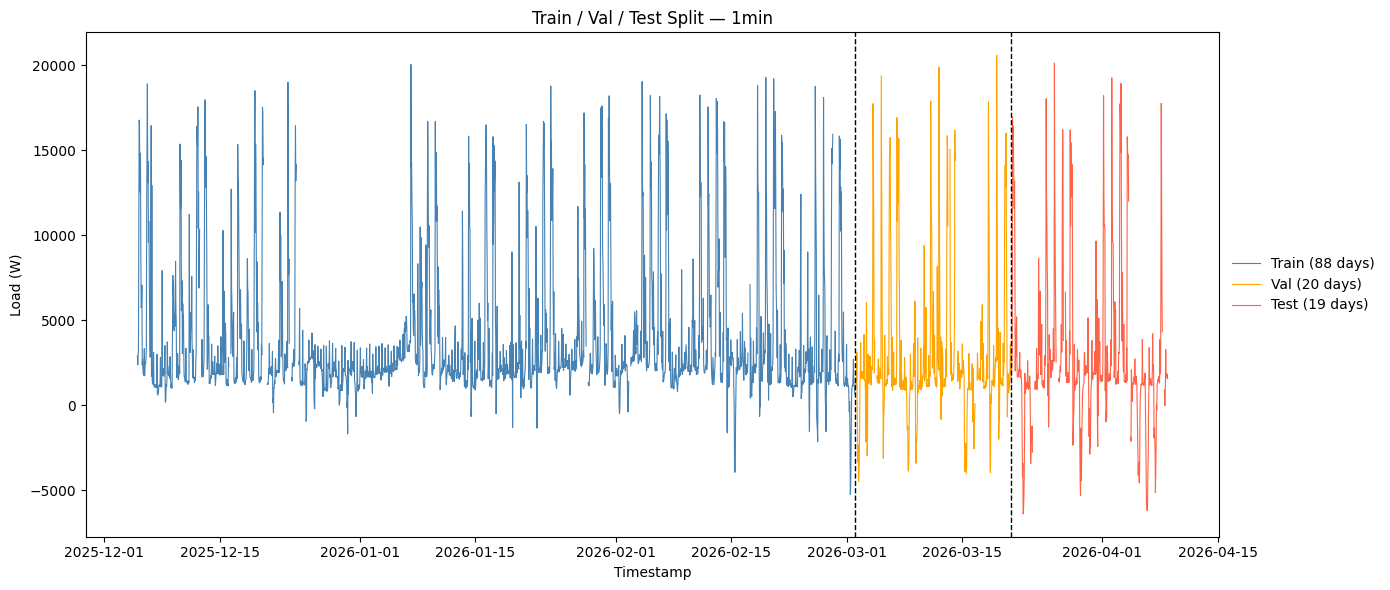


── 5min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (24901, 64)
  Val:   2026-03-02 → 2026-03-21 | (5473, 64)
  Test:  2026-03-21 → 2026-04-08 | (5472, 64)


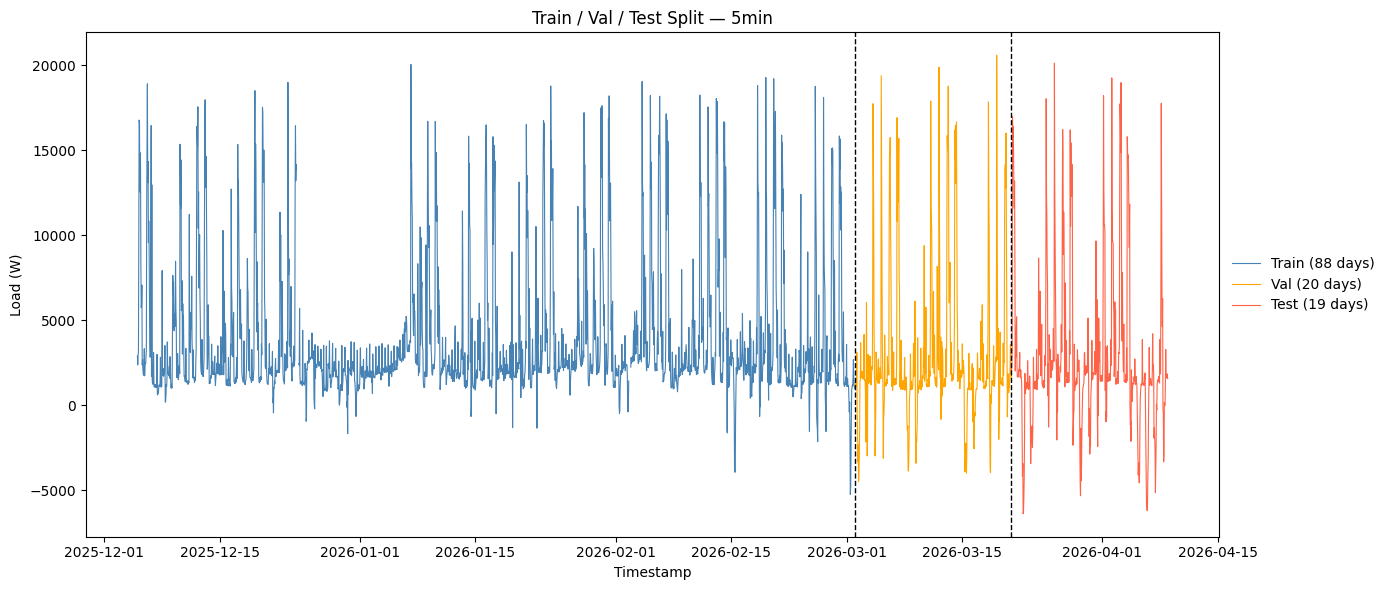


── 10min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (12489, 57)
  Val:   2026-03-02 → 2026-03-21 | (2737, 57)
  Test:  2026-03-21 → 2026-04-08 | (2736, 57)


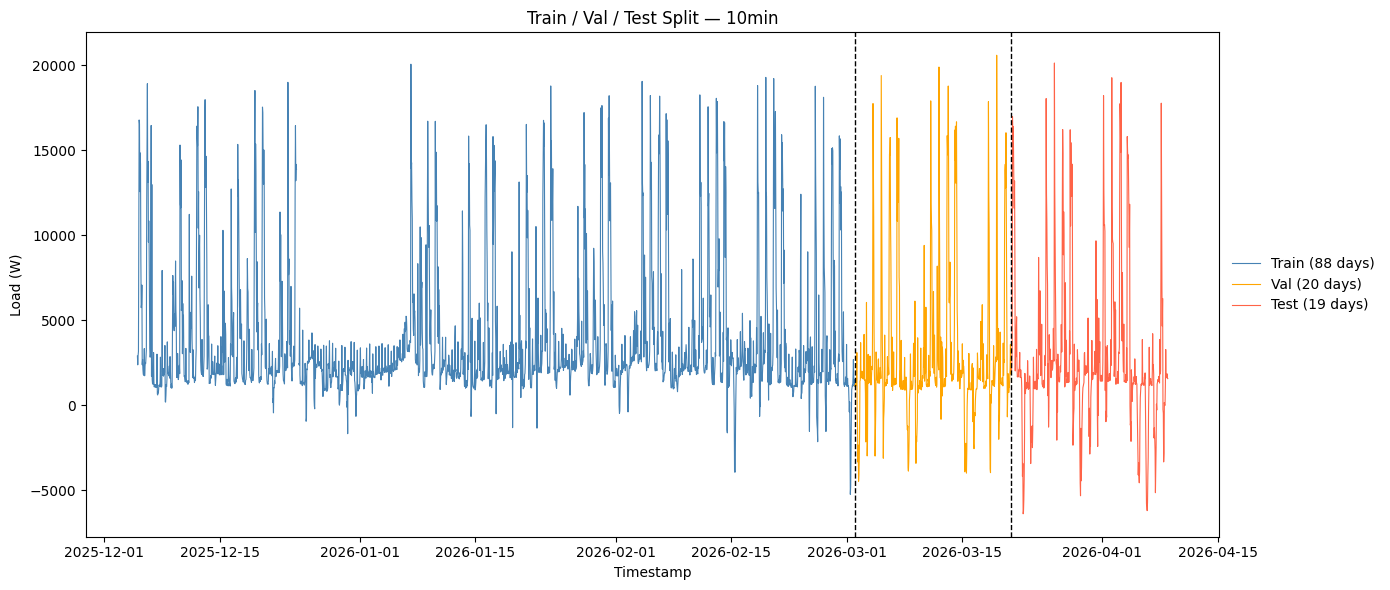


── 15min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (8353, 56)
  Val:   2026-03-02 → 2026-03-21 | (1825, 56)
  Test:  2026-03-21 → 2026-04-08 | (1824, 56)


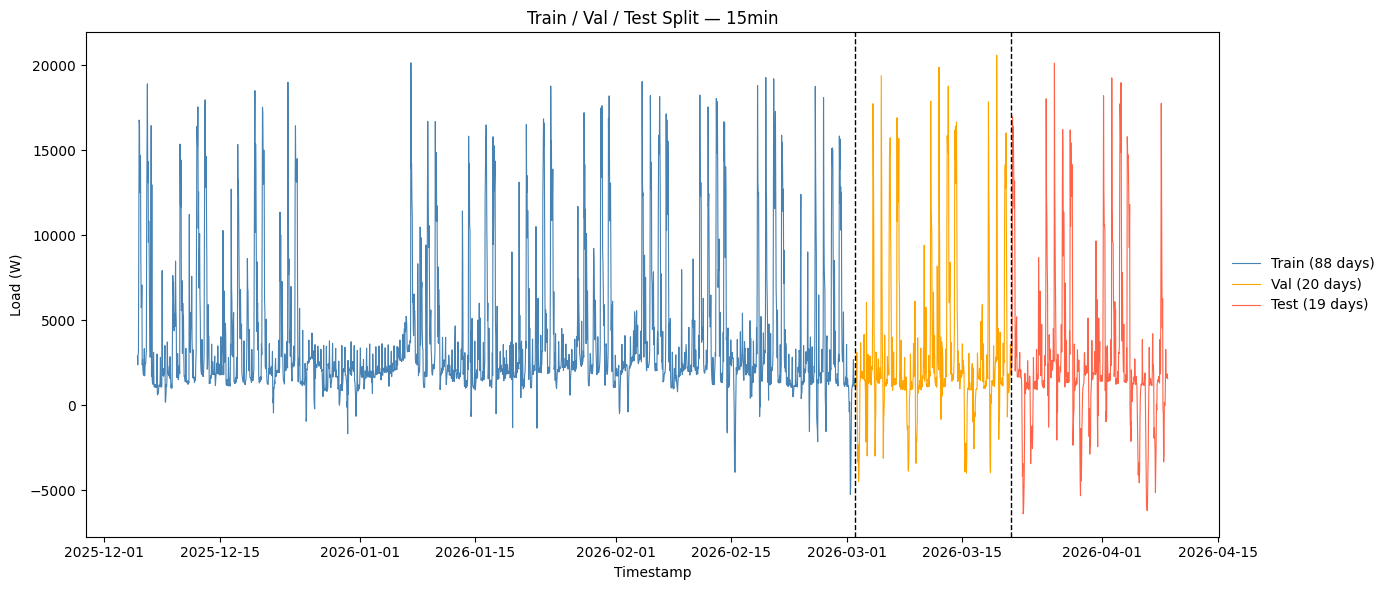


── 30min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (4177, 50)
  Val:   2026-03-02 → 2026-03-21 | (913, 50)
  Test:  2026-03-21 → 2026-04-08 | (912, 50)


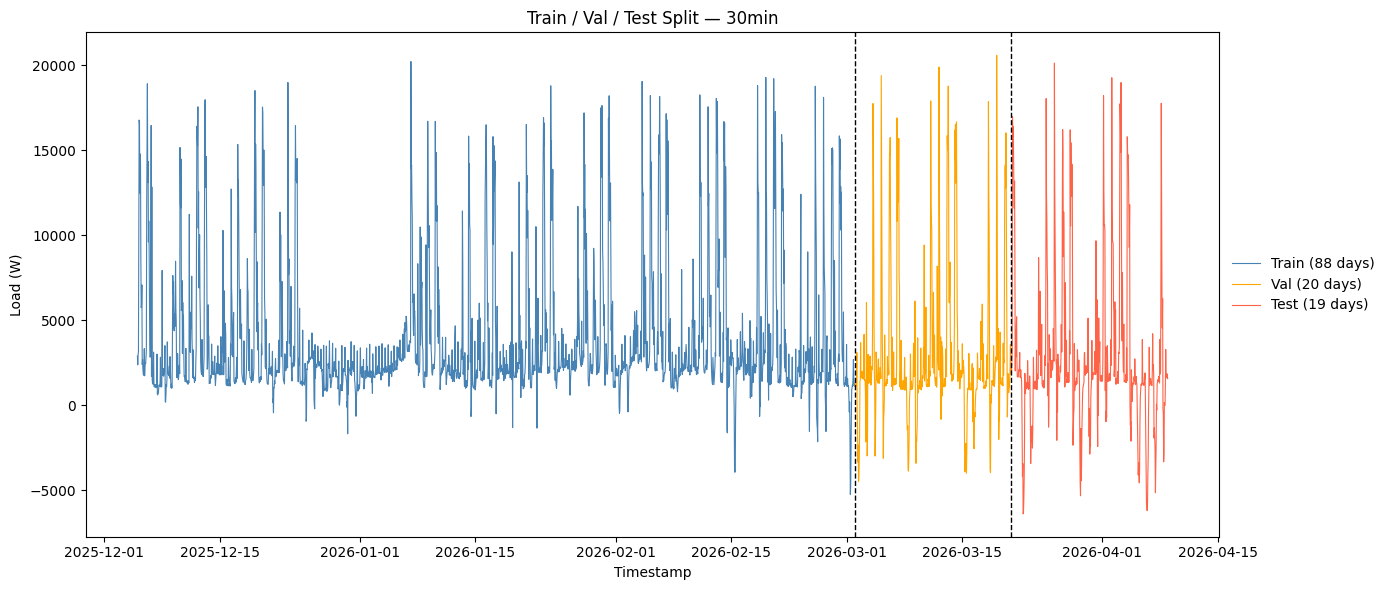


── 1h ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (2089, 49)
  Val:   2026-03-02 → 2026-03-21 | (457, 49)
  Test:  2026-03-21 → 2026-04-08 | (456, 49)


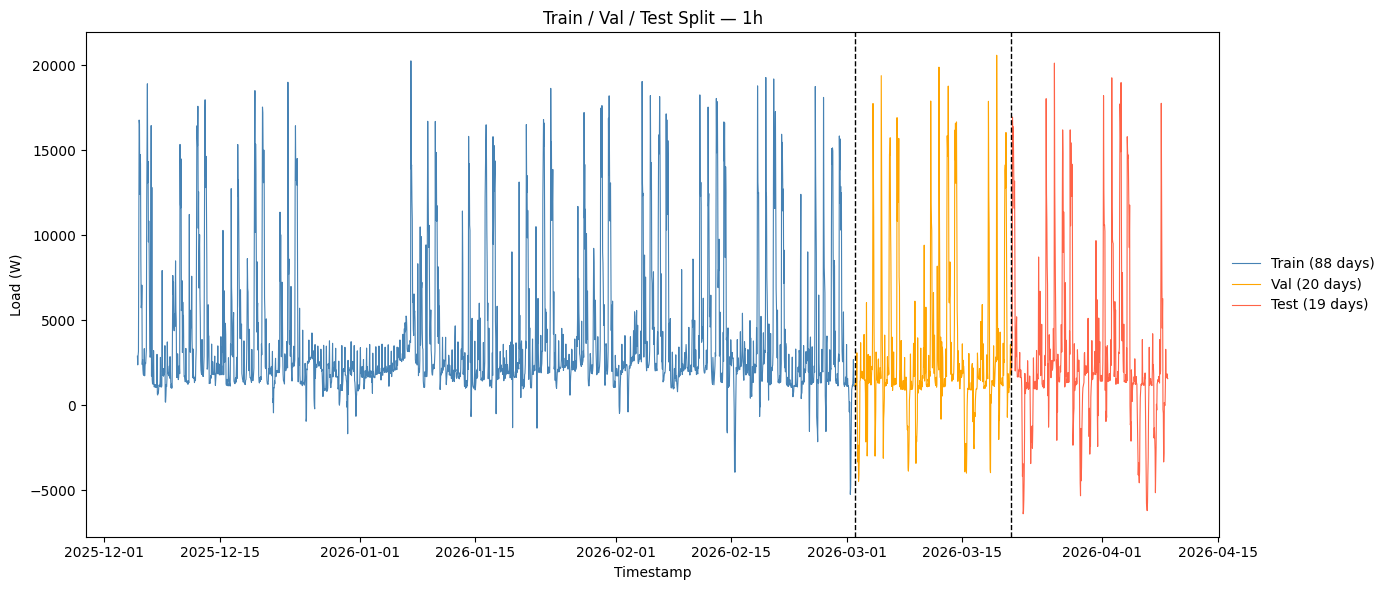

In [90]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
VAL_SIZE  = 0.15
TEST_SIZE = 0.15

CATEGORICAL_COLS = ["day_class"]
FLAG_COLS        = ["is_missing", "is_zero", "is_negative", "is_low_outlier", "is_high_outlier"]
# ─────────────────────────────────────────────────────────────────────────────


def train_val_test_split(df: pd.DataFrame, val_size: float = VAL_SIZE, test_size: float = TEST_SIZE):
    """Train/Val/Test split by percent of days, chronologically."""
    n_days = df.index.normalize().nunique()
    n_test = int(np.ceil(n_days * test_size))
    n_val  = int(np.ceil(n_days * val_size))

    dates     = df.index.normalize().unique().sort_values()
    val_date  = dates[-n_test - n_val]
    test_date = dates[-n_test]

    train = df.loc[:val_date]
    val   = df.loc[val_date:test_date]
    test  = df.loc[test_date:]
    return train, val, test


def plot_split(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame, resolution: str):
    """Visualize train/val/test split."""
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(train["load"].resample("1h").mean(), color="steelblue", linewidth=0.8, label=f"Train ({train.index.normalize().nunique()} days)")
    ax.plot(val["load"].resample("1h").mean(),   color="orange",    linewidth=0.8, label=f"Val ({val.index.normalize().nunique()} days)")
    ax.plot(test["load"].resample("1h").mean(),  color="tomato",    linewidth=0.8, label=f"Test ({test.index.normalize().nunique()} days)")

    ax.axvline(train.index.max(), color="black", linestyle="--", linewidth=1)
    ax.axvline(val.index.max(),   color="black", linestyle="--", linewidth=1)

    ax.set_title(f"Train / Val / Test Split — {resolution}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Load (W)")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


def preprocess(df: pd.DataFrame, resolution: str) -> tuple:
    """
    Generic preprocessing for all models and resolutions.
    - Drops missing and NaN rows
    - Keeps flag columns as features
    - Encodes categoricals
    - Returns df_train, df_val, df_test (X/y split happens per model)
    """
    df = df.copy()

    # 1. Drop missing load and NaN rows (warmup)
    df = df[~df["is_missing"]].dropna()

    # 2. Drop is_missing column (no longer needed), keep other flags as features
    df = df.drop(columns=["is_missing"])

    # 3. Encode day_class
    enc = OrdinalEncoder(categories=[["none", "half", "full"]])
    df["day_class"] = enc.fit_transform(df[["day_class"]])

    # 4. Split
    df_train, df_val, df_test = train_val_test_split(df)

    print(f"  Train: {df_train.index.min().date()} → {df_train.index.max().date()} | {df_train.shape}")
    print(f"  Val:   {df_val.index.min().date()} → {df_val.index.max().date()} | {df_val.shape}")
    print(f"  Test:  {df_test.index.min().date()} → {df_test.index.max().date()} | {df_test.shape}")

    plot_split(df_train, df_val, df_test, resolution)

    return df_train, df_val, df_test


# ── RUN ───────────────────────────────────────────────────────────────────────
dfs_preprocessed = {}
for res, df in dfs_featured.items():
    print(f"\n── {res} ──────────────────────────────")
    df_train, df_val, df_test = preprocess(df, res)
    dfs_preprocessed[res] = {
        "train": df_train,
        "val":   df_val,
        "test":  df_test
    }

# Access like:
#df_train = dfs_preprocessed["1min"]["train"]
#df_val   = dfs_preprocessed["1min"]["val"]
#df_test  = dfs_preprocessed["1min"]["test"]

In [91]:
# Ensure all day classifications are being tested
train_raw, val_raw, test_raw = train_val_test_split(dfs_featured["1min"])

for name, split in [("Train", train_raw), ("Val", val_raw), ("Test", test_raw)]:
    dist = split.groupby(split.index.normalize())["day_class"].first().value_counts()
    pct  = (dist / dist.sum() * 100).round(1)
    print(f"\n{name} ({split.index.normalize().nunique()} days):")
    print(pd.DataFrame({"days": dist, "%": pct}).to_string())


Train (93 days):
           days     %
day_class            
full         41  44.1
none         30  32.3
half         22  23.7

Val (21 days):
           days     %
day_class            
full         12  57.1
half          5  23.8
none          4  19.0

Test (20 days):
           days     %
day_class            
full         11  55.0
half          5  25.0
none          4  20.0


### Save Data

In [97]:
for res, splits in dfs_preprocessed.items():
  for split in splits:
    df = dfs_preprocessed[res][split]
    save_preprocessed(df, res, split)

✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/1min_train_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/1min_val_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/1min_test_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/5min_train_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/5min_val_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/5min_test_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/10min_train_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/10min_val_load.parquet
✓ Successfully save data to /content/drive/MyDrive/ElectricLoa

## Step 6 Baseline Modeling

The baseline model predicts load using the **mean of the last 6 occurrences** of the same time and day class in the training data.

For each timestamp to predict, the baseline:
1. Looks back in the training data for the same **time of day** and **day class**
2. Takes the **last 6 occurrences** of that time + day class
3. Computes the **mean** of those 6 values as the prediction

If fewer than 6 occurrences exist, the mean of however many are available is used.

**Example**:

Predicting `2026-04-08 08:30:00` on a `full` day at `1min` resolution:

Look back in training data at all `full` day `08:30:00` values, take the last 6:

| Date | Day Class | Load at 08:30 |
|------|-----------|---------------|
| 2026-04-07 | full | 1,820W |
| 2026-04-06 | full | 1,950W |
| 2026-04-03 | full | 2,100W |
| 2026-04-02 | full | 1,780W |
| 2026-04-01 | full | 2,050W |
| 2026-03-31 | full | 1,900W |

```
Baseline prediction = (1820 + 1950 + 2100 + 1780 + 2050 + 1900) / 6 = 1,933W
```

The same logic is applied independently for every timestamp and day class combination in the forecast profile.

**Why This Baseline?**

- Simple and interpretable — no model training required
- Captures daily and weekly load patterns naturally
- Robust to individual anomalous days since it averages across 6 occurrences
- Sets a meaningful benchmark — any model that cannot beat this is not useful

### Define Model

In [119]:
class BaselineModel:
    """
    Baseline model that predicts load using the mean of the last N occurrences
    of the same time and day_class in the training data.
    """

    def __init__(self, n: int = 6):
        self.n          = n
        self.lookup_    = None
        self.is_fitted_ = False

    def fit(self, df: pd.DataFrame) -> "BaselineModel":
        """Build lookup table from training data."""
        df = df.copy()
        df["time"] = df.index.time

        rows = []
        for (time, day_class), group in df.groupby(["time", "day_class"]):
            values = group["load"].dropna().tail(self.n)
            if len(values) == 0:
                raise ValueError(f"No samples found for time={time}, day_class={day_class}")
            rows.append({
                "time":           time,
                "day_class":      day_class,
                "predicted_load": values.mean(),
                "n_samples":      len(values)
            })

        self.lookup_    = pd.DataFrame(rows)
        self.is_fitted_ = True

        sample_counts = self.lookup_["n_samples"].value_counts().sort_index(ascending=False)

        print(f"BaselineModel fitted for n = {self.n}")
        print(f"Lookup shape: {self.lookup_.shape}")
        print(f"Sample counts:")
        for n, count in sample_counts.items():
            print(f"  {n}: {count}")

        return self

    def predict(self, df: pd.DataFrame) -> pd.Series:
        """Predict load using the lookup table."""
        if not self.is_fitted_:
            raise ValueError("Model is not fitted. Call fit() first.")

        df = df.copy()
        df["time"] = df.index.time
        df = df.merge(self.lookup_[["time", "day_class", "predicted_load"]], on=["time", "day_class"], how="left")

        missing = df["predicted_load"].isna().sum()
        print(f"Predicted {len(df):,} values | Missing lookups: {missing}")

        return df["predicted_load"]

### Train

In [131]:
baselines = {}

for res, splits in dfs_preprocessed.items():

    print(f"\n── Training Baseline {res} ──────────────────────────────")

    df_train = splits["train"]
    model = BaselineModel(n=6)
    model.fit(df_train)

    baselines[res] = {"model": model}


── Baseline 1min ──────────────────────────────
BaselineModel fitted for n = 6
Lookup shape: (4320, 4)
Sample counts:
  6: 4320

── Baseline 5min ──────────────────────────────
BaselineModel fitted for n = 6
Lookup shape: (864, 4)
Sample counts:
  6: 864

── Baseline 10min ──────────────────────────────
BaselineModel fitted for n = 6
Lookup shape: (432, 4)
Sample counts:
  6: 432

── Baseline 15min ──────────────────────────────
BaselineModel fitted for n = 6
Lookup shape: (288, 4)
Sample counts:
  6: 288

── Baseline 30min ──────────────────────────────
BaselineModel fitted for n = 6
Lookup shape: (144, 4)
Sample counts:
  6: 144

── Baseline 1h ──────────────────────────────
BaselineModel fitted for n = 6
Lookup shape: (72, 4)
Sample counts:
  6: 72


### Predict

In [144]:
for res, splits in dfs_preprocessed.items():

    print(f"\n── Predicting Baseline {res} ──────────────────────────────")

    # Predict
    df_val   = splits["val"]
    df_test  = splits["test"]
    model = baselines[res]["model"]

    baselines[res]["val_true"] = df_val
    baselines[res]["test_true"] = df_test
    baselines[res]["val_pred"]  =  model.predict(df_val)
    baselines[res]["test_pred"] = model.predict(df_test)



── Predicting Baseline 1min ──────────────────────────────
Predicted 25,901 values | Missing lookups: 0
Predicted 25,497 values | Missing lookups: 0

── Predicting Baseline 5min ──────────────────────────────
Predicted 5,473 values | Missing lookups: 0
Predicted 5,472 values | Missing lookups: 0

── Predicting Baseline 10min ──────────────────────────────
Predicted 2,737 values | Missing lookups: 0
Predicted 2,736 values | Missing lookups: 0

── Predicting Baseline 15min ──────────────────────────────
Predicted 1,825 values | Missing lookups: 0
Predicted 1,824 values | Missing lookups: 0

── Predicting Baseline 30min ──────────────────────────────
Predicted 913 values | Missing lookups: 0
Predicted 912 values | Missing lookups: 0

── Predicting Baseline 1h ──────────────────────────────
Predicted 457 values | Missing lookups: 0
Predicted 456 values | Missing lookups: 0


### Evaluate

In [165]:
def evaluate(y_true: pd.Series, y_pred: pd.Series) -> dict:
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    wape = (abs(y_true - y_pred).sum() / abs(y_true).sum()) * 100

    print(f"MAE: {mae:.1f} | RMSE: {rmse:.1f} | WAPE: {wape:.1f}%")
    return {"mae": mae, "rmse": rmse, "wape": wape}

def plot_eval(y_true: pd.Series, y_pred: pd.Series, title: str = None):
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)

    # Compute metrics
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    wape = (abs(y_true - y_pred).sum() / abs(y_true).sum()) * 100

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(y_true.values, color="steelblue", linewidth=0.8, label="Actual")
    ax.plot(y_pred.values, color="tomato",    linewidth=0.8, label="Predicted", alpha=0.8)

    ax.set_title(f"{title or 'Actual vs Predicted'} (MAE: {mae:.1f} | RMSE: {rmse:.1f} | WAPE: {wape:.1f}%)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Load (W)")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

for res, splits in dfs_preprocessed.items():

    print(f"\n── Evaluating Baseline {res} ──────────────────────────────")

    # Evaluate
    df_val   = baselines[res]["val_true"]
    df_test  = baselines[res]["test_true"]
    val_pred = baselines[res]["val_pred"]
    test_pred = baselines[res]["test_pred"]
    print("Val --", end = " ")
    baselines[res]["val_metrics"]  = evaluate(df_val["load"],  val_pred)
    print("Test --", end = " ")
    baselines[res]["test_metrics"] = evaluate(df_test["load"], test_pred)


── Evaluating Baseline 1min ──────────────────────────────
Val -- MAE: 2644.3 | RMSE: 3957.3 | WAPE: 78.5%
Test -- MAE: 2996.1 | RMSE: 4624.5 | WAPE: 80.3%

── Evaluating Baseline 5min ──────────────────────────────
Val -- MAE: 2667.3 | RMSE: 3964.5 | WAPE: 76.3%
Test -- MAE: 3010.6 | RMSE: 4565.5 | WAPE: 80.8%

── Evaluating Baseline 10min ──────────────────────────────
Val -- MAE: 2575.7 | RMSE: 3846.7 | WAPE: 74.3%
Test -- MAE: 2922.8 | RMSE: 4448.3 | WAPE: 78.9%

── Evaluating Baseline 15min ──────────────────────────────
Val -- MAE: 2532.3 | RMSE: 3771.6 | WAPE: 73.2%
Test -- MAE: 2870.6 | RMSE: 4361.5 | WAPE: 77.8%

── Evaluating Baseline 30min ──────────────────────────────
Val -- MAE: 2404.5 | RMSE: 3587.6 | WAPE: 70.3%
Test -- MAE: 2745.7 | RMSE: 4160.9 | WAPE: 74.9%

── Evaluating Baseline 1h ──────────────────────────────
Val -- MAE: 2271.4 | RMSE: 3359.9 | WAPE: 67.4%
Test -- MAE: 2620.7 | RMSE: 3956.6 | WAPE: 72.5%


### Plot


── Plot Baseline 1min ──────────────────────────────


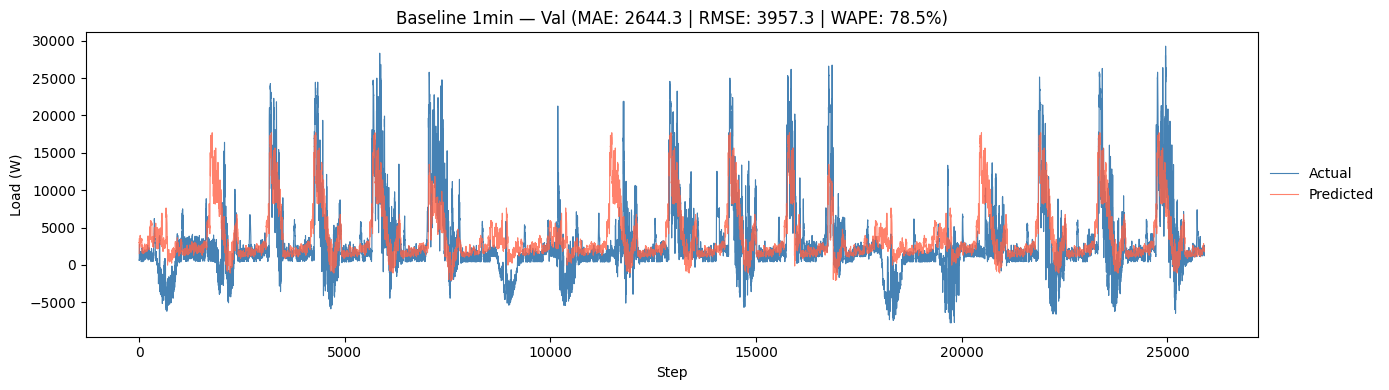

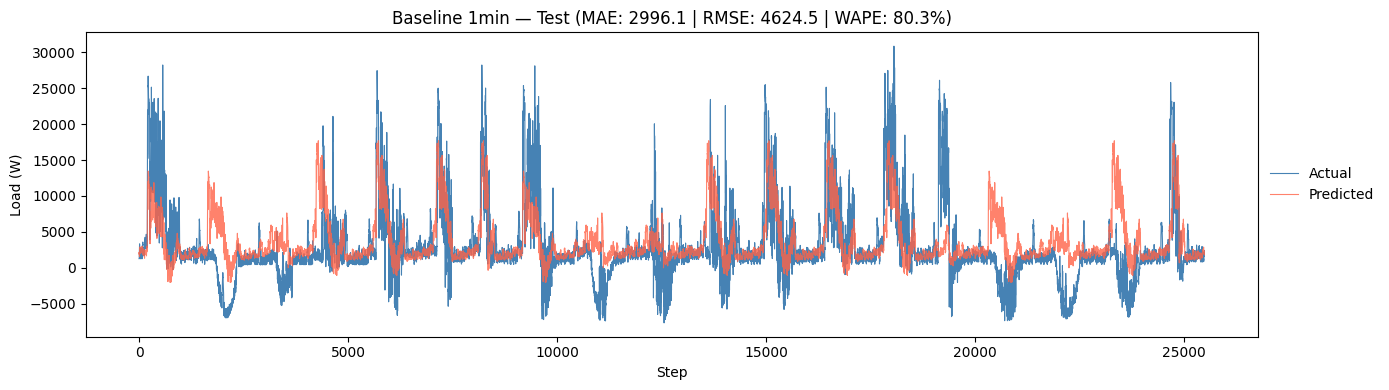


── Plot Baseline 5min ──────────────────────────────


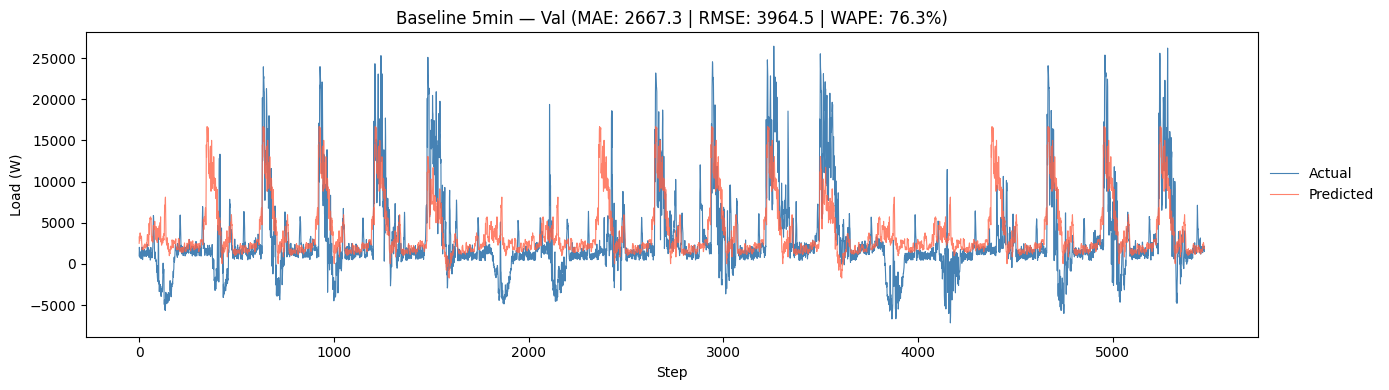

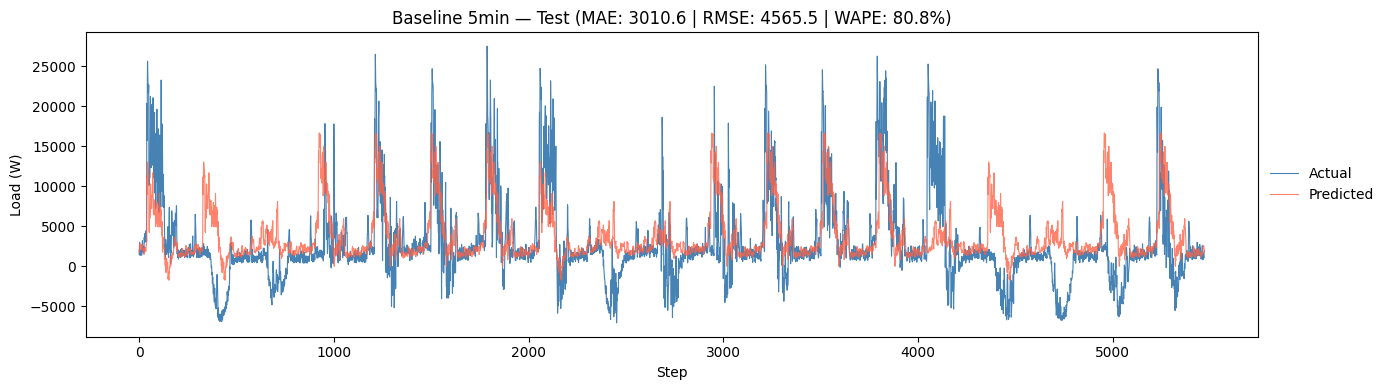


── Plot Baseline 10min ──────────────────────────────


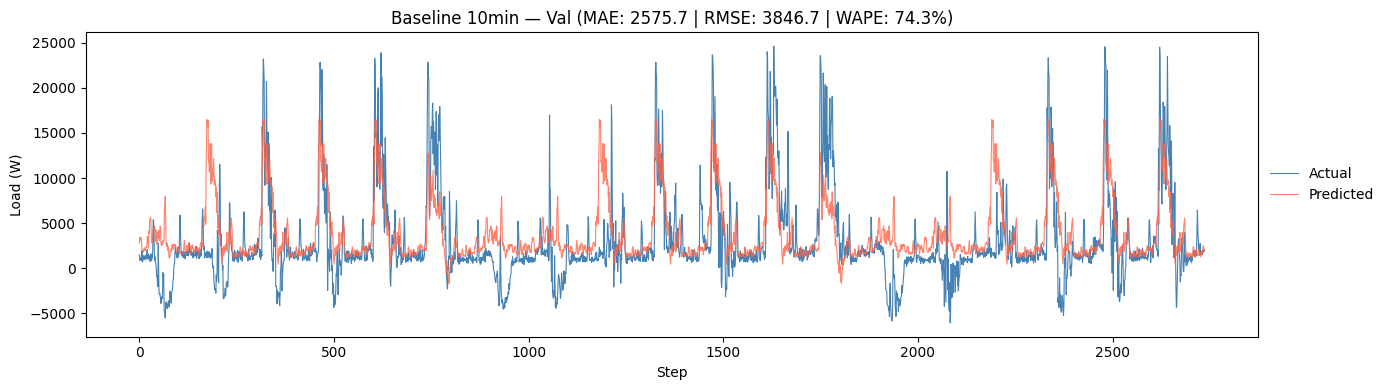

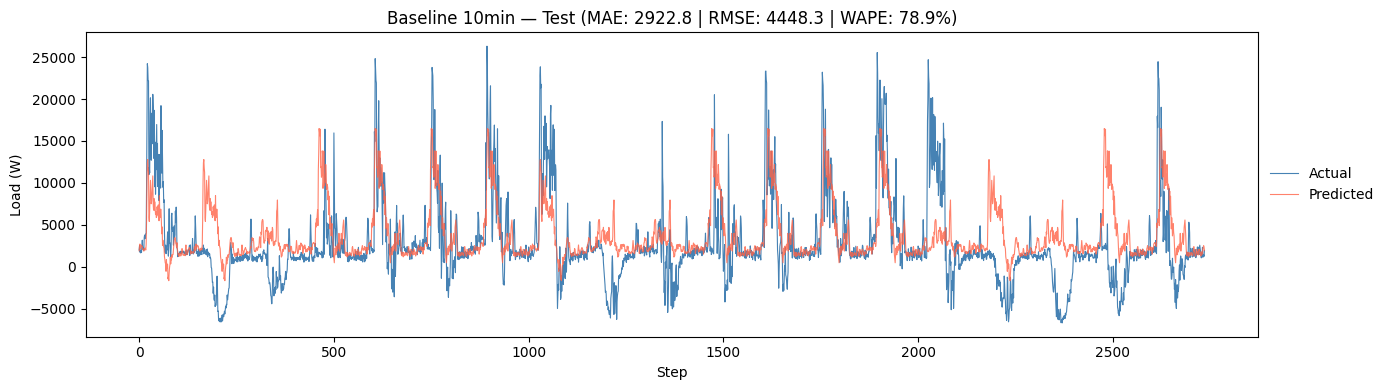


── Plot Baseline 15min ──────────────────────────────


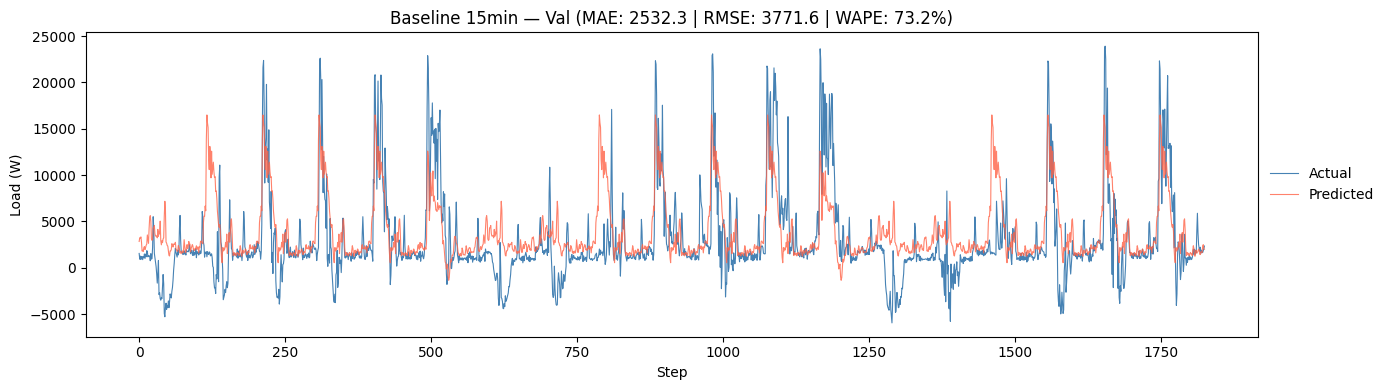

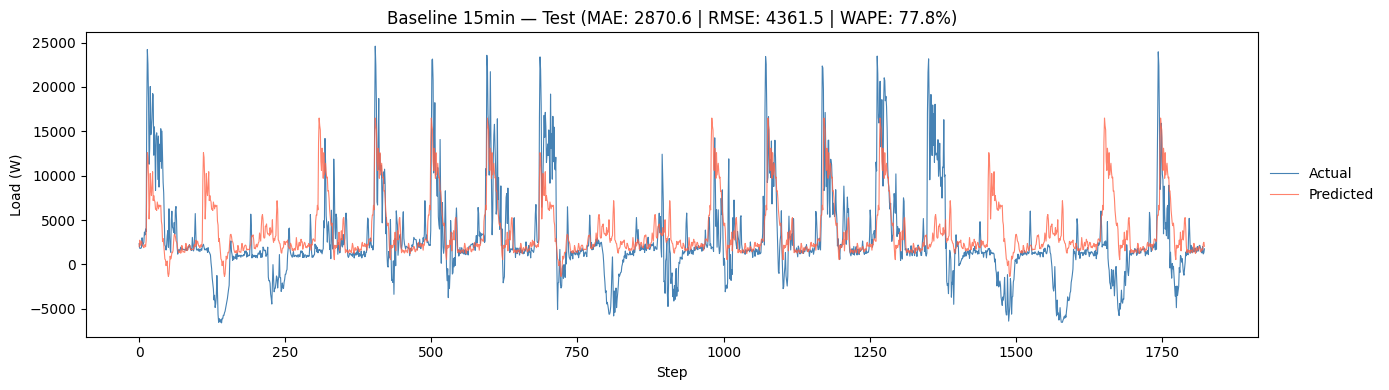


── Plot Baseline 30min ──────────────────────────────


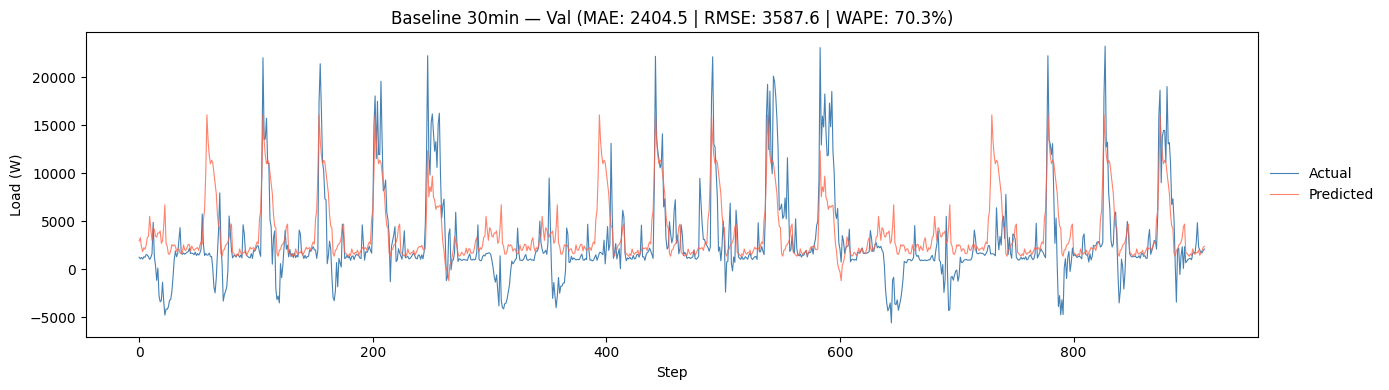

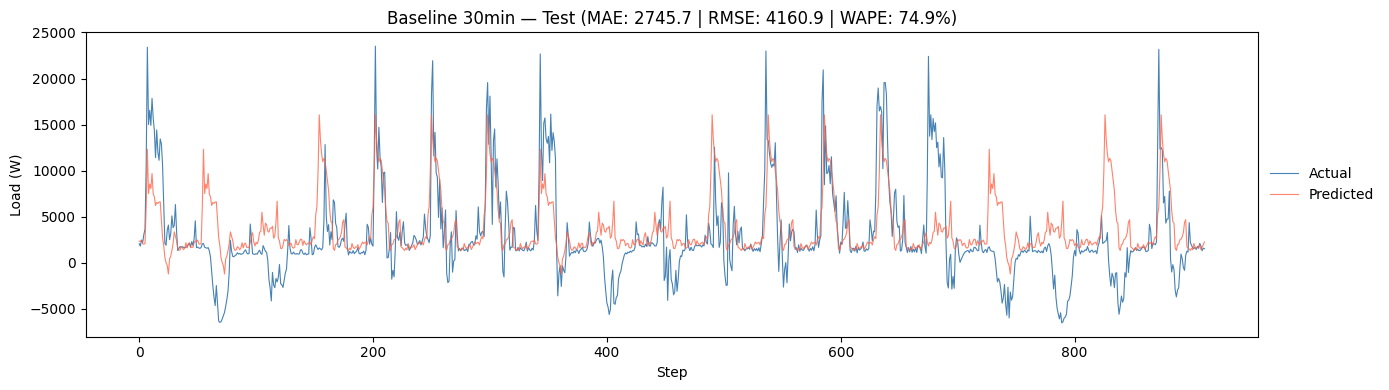


── Plot Baseline 1h ──────────────────────────────


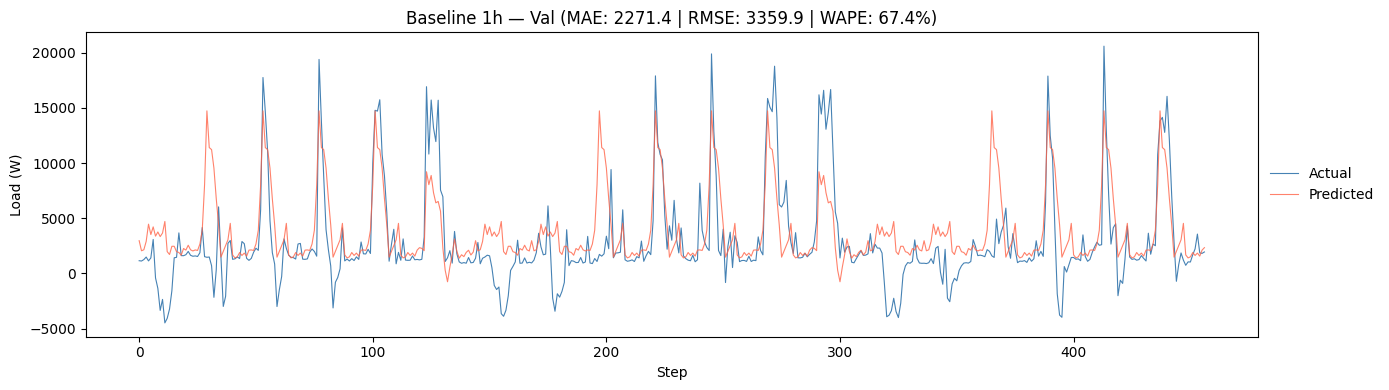

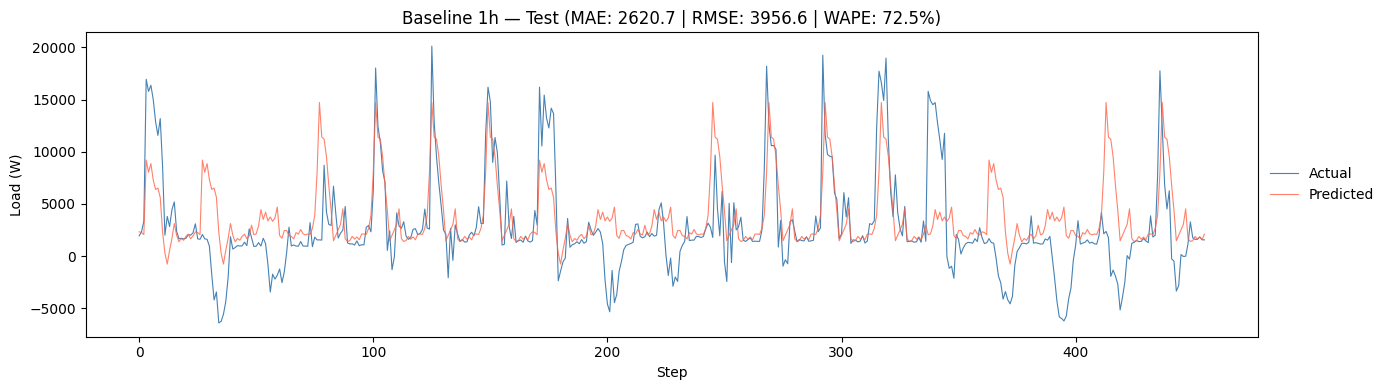

In [168]:
for res, data in baselines.items():
  print(f"\n── Plot Baseline {res} ──────────────────────────────")
  plot_eval(data["val_true"]["load"], data["val_pred"], title=f"Baseline {res} — Val")
  plot_eval(data["test_true"]["load"], data["test_pred"], title=f"Baseline {res} — Test")

### Save

In [169]:
for res, data in baselines.items():
    print(f"\n── Baseline {res} ──────────────────────────────")
    save_model(data["model"], "baseline", res)
    save_predictions(data["val_pred"].to_frame("predicted_load"), "baseline", res, "val")
    save_predictions(data["test_pred"].to_frame("predicted_load"), "baseline", res, "test")
    save_evaluations(data["val_metrics"], "baseline", res)
    save_evaluations(data["test_metrics"], "baseline", res)
    save_actuals(data["val_true"]["load"].to_frame("load"), res, "val")
    save_actuals(data["test_true"]["load"].to_frame("load"), res, "test")


── Baseline 1min ──────────────────────────────
✓ Saved model to /content/drive/MyDrive/ElectricLoadForecast/data/006_models/baseline_1min.joblib
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions/baseline_1min_val.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions/baseline_1min_test.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/008_evaluations/baseline_1min.json
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/008_evaluations/baseline_1min.json
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions/actual_1min_val.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions/actual_1min_test.parquet

── Baseline 5min ──────────────────────────────
✓ Saved model to /content/drive/MyDrive/ElectricLoadForecast/data/006_models/baseline_5min.joblib
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions/baseli

## Step 7: Model Training

### XG Boost

Train

In [ ]:
FEATURES = ['day_class_full', 'day_class_half', 'day_class_none', 'hour_sin', 'dow_sin', 'month_sin']
#FEATURES = [c for c in df_features.columns if c != 'load']
TARGET = 'load'

X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

y_train = train[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

reg = xgb.XGBRegressor(n_estimators=10000, early_stopping_rounds=50, learning_rate=0.01)
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:4472.19453	validation_1-rmse:5045.86793
[100]	validation_0-rmse:3266.83577	validation_1-rmse:3800.77686
[200]	validation_0-rmse:3045.17264	validation_1-rmse:3548.05329
[300]	validation_0-rmse:2992.53750	validation_1-rmse:3468.48149
[400]	validation_0-rmse:2971.29769	validation_1-rmse:3428.71833
[500]	validation_0-rmse:2958.87400	validation_1-rmse:3403.80916
[600]	validation_0-rmse:2952.75924	validation_1-rmse:3392.79820
[700]	validation_0-rmse:2948.44469	validation_1-rmse:3389.28279
[800]	validation_0-rmse:2944.92134	validation_1-rmse:3387.42149
[900]	validation_0-rmse:2942.44215	validation_1-rmse:3386.71289
[1000]	validation_0-rmse:2938.84506	validation_1-rmse:3384.51141
[1100]	validation_0-rmse:2936.96932	validation_1-rmse:3383.78419
[1200]	validation_0-rmse:2935.46797	validation_1-rmse:3382.06123
[1254]	validation_0-rmse:2934.34348	validation_1-rmse:3382.34991


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

Feature Importance

<Axes: title={'center': 'Feature Importance'}>

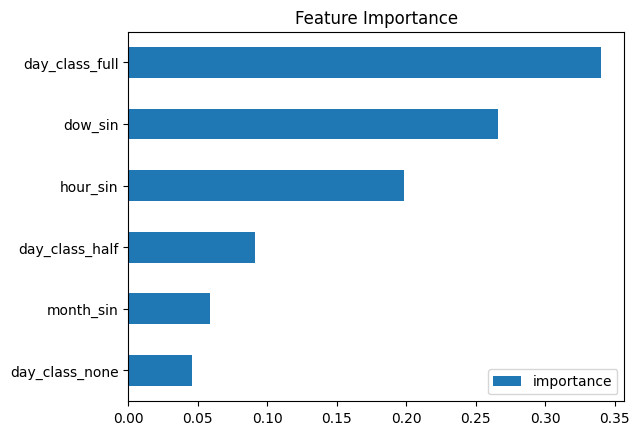

In [ ]:
fi = pd.DataFrame(data=reg.feature_importances_, index = reg.feature_names_in_, columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')

Forecast

In [ ]:
pred_val  = reg.predict(X_val)
pred_test = reg.predict(X_test)